Electric Vehicle Population Data — Complete EDA
This notebook performs a comprehensive Exploratory Data Analysis on EV population data, featuring dark-themed visualizations and dataset splitting based on Electric Range.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#1A1D27',
    'axes.edgecolor':   '#3A3D4A',
    'axes.labelcolor':  '#E0E0E0',
    'xtick.color':      '#B0B0B0',
    'ytick.color':      '#B0B0B0',
    'text.color':       '#E0E0E0',
    'grid.color':       '#2A2D3A',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   10,
    'axes.labelsize':   8,
    'xtick.labelsize':  7,
    'ytick.labelsize':  7,
})

# Dataset color palette:  Blue = All | Red = Range > 0 | Green = Range = 0
PALETTE = ['#4F86F7', '#F75A4F', '#4FF77B']
ALPHA   = 0.80

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the dataset
df = pd.read_csv('Electric_Vehicle_Population_Data.csv')

# Create splits based on range
df_pos  = df[df['Electric Range'] > 0].copy()
df_zero = df[df['Electric Range'] == 0].copy()

datasets = [df,    df_pos,       df_zero    ]
labels   = ['All', 'Range > 0',  'Range = 0']
colors   = PALETTE

print(f"All     rows : {len(df):,}")
print(f"Range > 0   : {len(df_pos):,}  ({len(df_pos)/len(df)*100:.1f}%)")
print(f"Range = 0   : {len(df_zero):,}  ({len(df_zero)/len(df)*100:.1f}%)")
print("\nColumns:", df.columns.tolist())

All     rows : 279,780
Range > 0   : 101,832  (36.4%)
Range = 0   : 177,937  (63.6%)

Columns: ['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']


Plotting Heatmap of correlation.
Legislative district and cencus tract has no contribution to Electric Range

In [16]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JN1AZ0CP5C,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,153331706,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
1,JTMABABA7P,Yakima,Yakima,WA,98903.0,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,253586308,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10
2,1N4AZ1CP1J,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5UX43EU09S,Kitsap,Poulsbo,WA,98370.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,267525737,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10
4,3C3CFFGE5F,Thurston,Yelm,WA,98597.0,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,474468501,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


In [17]:
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,279756.000000,279780.000000,279769.000000,279080.000000,2.797800e+05,2.797560e+05
mean,98176.111447,2022.074072,39.172256,28.827841,2.462994e+08,5.297189e+10
std,2577.398040,3.059852,78.230356,14.908133,6.346205e+07,1.636194e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.213867e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.629453e+08,5.303303e+10
75%,98382.000000,2024.000000,32.000000,42.000000,2.790832e+08,5.305394e+10
max,99517.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279780 entries, 0 to 279779
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         279780 non-null  object 
 1   County                                             279756 non-null  object 
 2   City                                               279756 non-null  object 
 3   State                                              279780 non-null  object 
 4   Postal Code                                        279756 non-null  float64
 5   Model Year                                         279780 non-null  int64  
 6   Make                                               279780 non-null  object 
 7   Model                                              279780 non-null  object 
 8   Electric Vehicle Type                              279780 non-null  object

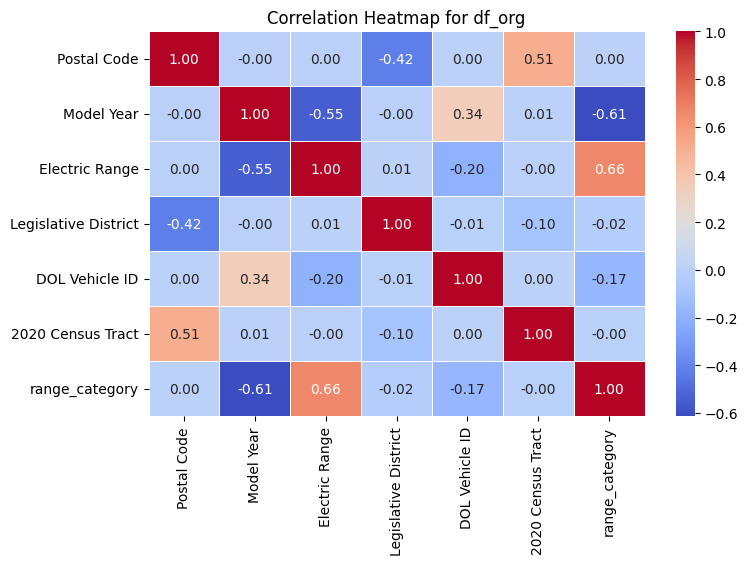

In [16]:
# 1. Calculate the correlation matrix
# Note: numeric_only=True ensures we only calculate correlation for numbers
corr_matrix = df_org.corr(numeric_only=True)

# 2. Set up the matplotlib figure size
plt.figure(figsize=(8, 5))

# 3. Create the heatmap
sns.heatmap(corr_matrix, 
            annot=True,       # Shows the numbers in the cells
            cmap='coolwarm',  # Color scheme (red for positive, blue for negative)
            fmt=".2f",        # Rounds numbers to 2 decimal places
            linewidths=0.5)   # Adds thin lines between cells for clarity

# 4. Add a title and show the plot
plt.title('Correlation Heatmap for df_org')
plt.show()

<Axes: xlabel='Electric Vehicle Type', ylabel='count'>

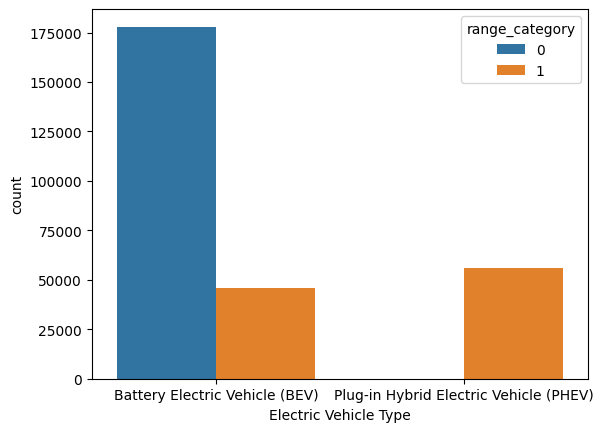

In [9]:
df_org['range_category'] = np.where(df_org['Electric Range'] > 0, 1, 0)
sns.countplot(x='Electric Vehicle Type',hue='range_category',data=df_org)

Relation between model year and Electric Range

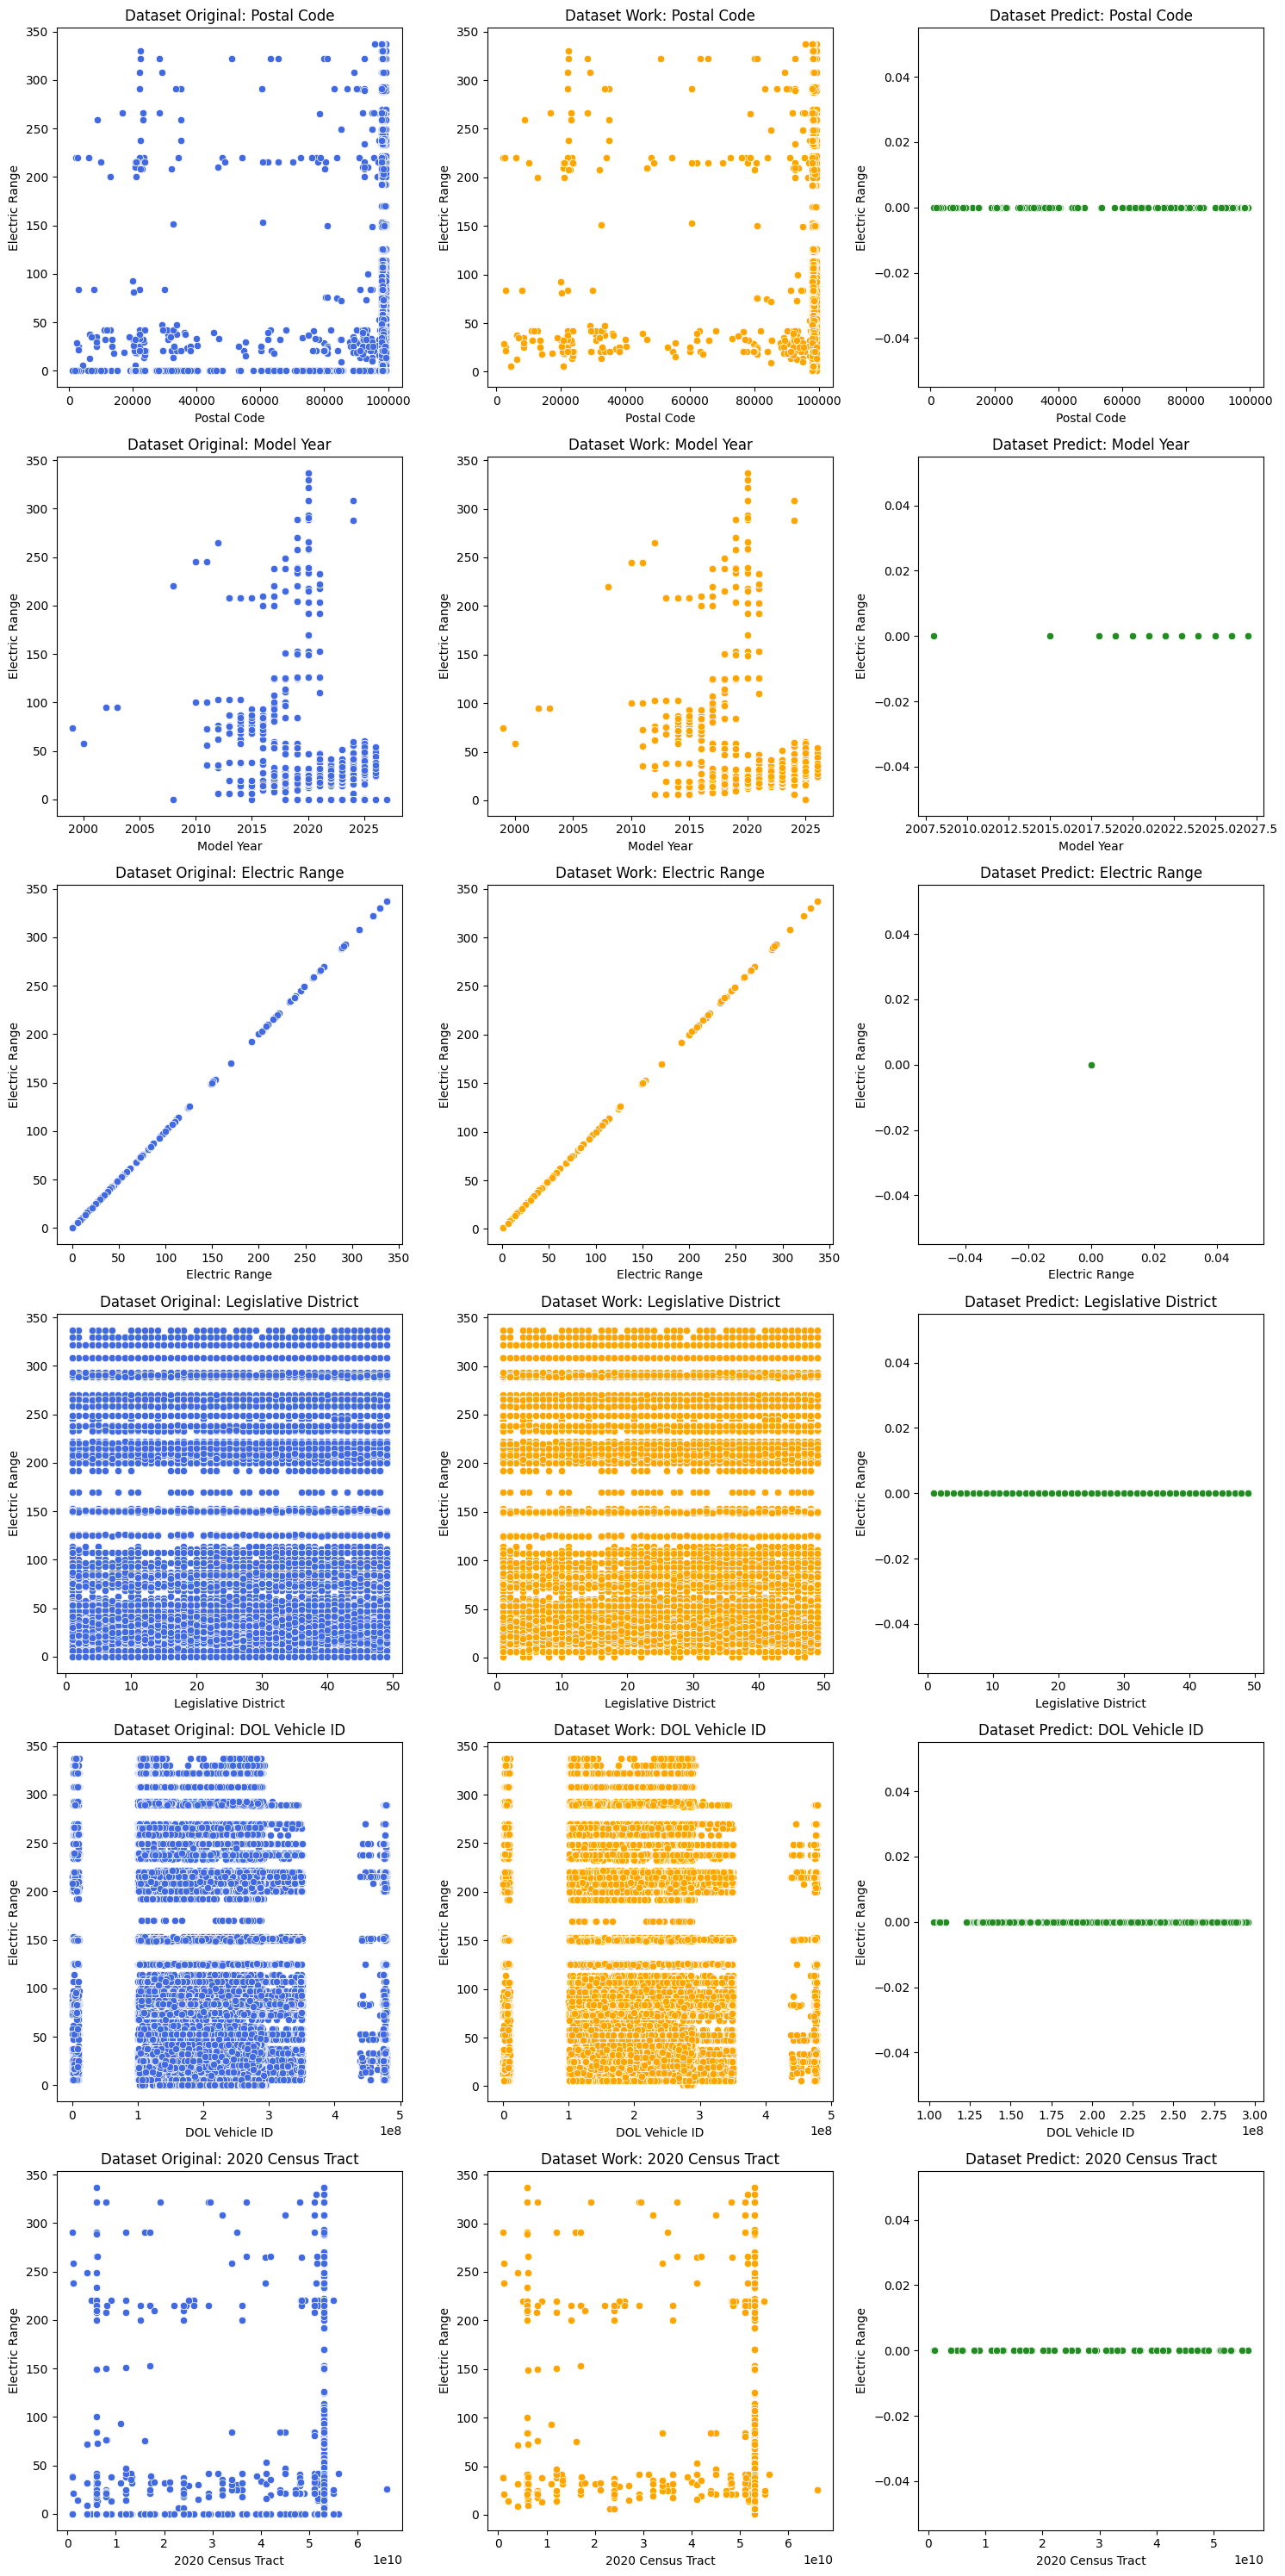

In [15]:
# 1. Adjusted to 6 rows and 3 columns to match your 'axes' indexing
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(15, 30))

# 3. Iterate through the columns
for i, col in enumerate(cols_num):
    # Ensure we don't go out of bounds if cols_num has more than 6 items
    if i >= 6: break 
    
    # FIX: x=col (the variable), not x='col' (the string literal)
    
    # Plot Dataset Original
    sns.scatterplot(x=col, y='Electric Range', ax=axes[i, 0], color='royalblue', data=df_org)
    axes[i, 0].set_title(f'Dataset Original: {col}', fontsize=12)
    
    # Plot Dataset Work
    sns.scatterplot(x=col, y='Electric Range', ax=axes[i, 1], color='orange', data=df)
    axes[i, 1].set_title(f'Dataset Work: {col}', fontsize=12)

    # Plot Dataset Predict
    # FIX: Corrected index to axes[i, 2] for the third column
    sns.scatterplot(x=col, y='Electric Range', ax=axes[i, 2], color='forestgreen', data=df2)
    axes[i, 2].set_title(f'Dataset Predict: {col}', fontsize=12)
    
# 4. Clean up the labels and layout
plt.tight_layout()
plt.show()

In [3]:
print("=" * 55)
print("SHAPE & DTYPES")
print("=" * 55)
print(df.dtypes)

print("\n" + "=" * 55)
print("MISSING VALUES")
print("=" * 55)
print(df.isnull().sum())

print("\n" + "=" * 55)
print("ELECTRIC RANGE — DESCRIPTIVE STATS")
print("=" * 55)
print(df['Electric Range'].describe())

SHAPE & DTYPES
VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Census Tract                                    float64
dtype: ob

In [4]:
def style_ax(ax, title='', xlabel='', ylabel=''):
    """Apply consistent dark-theme styling to an axes."""
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, axis='y', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

def add_badge(ax, label, color):
    """Add a colored dataset badge inside the top-right corner of an axes."""
    ax.text(
        0.98, 0.97, label,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=8, fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.85, edgecolor='none')
    )

print("Helper functions ready.")

Helper functions ready.


Section 1: Numeric EDA
Exploring distributions, outliers, and statistical comparisons across numeric features.

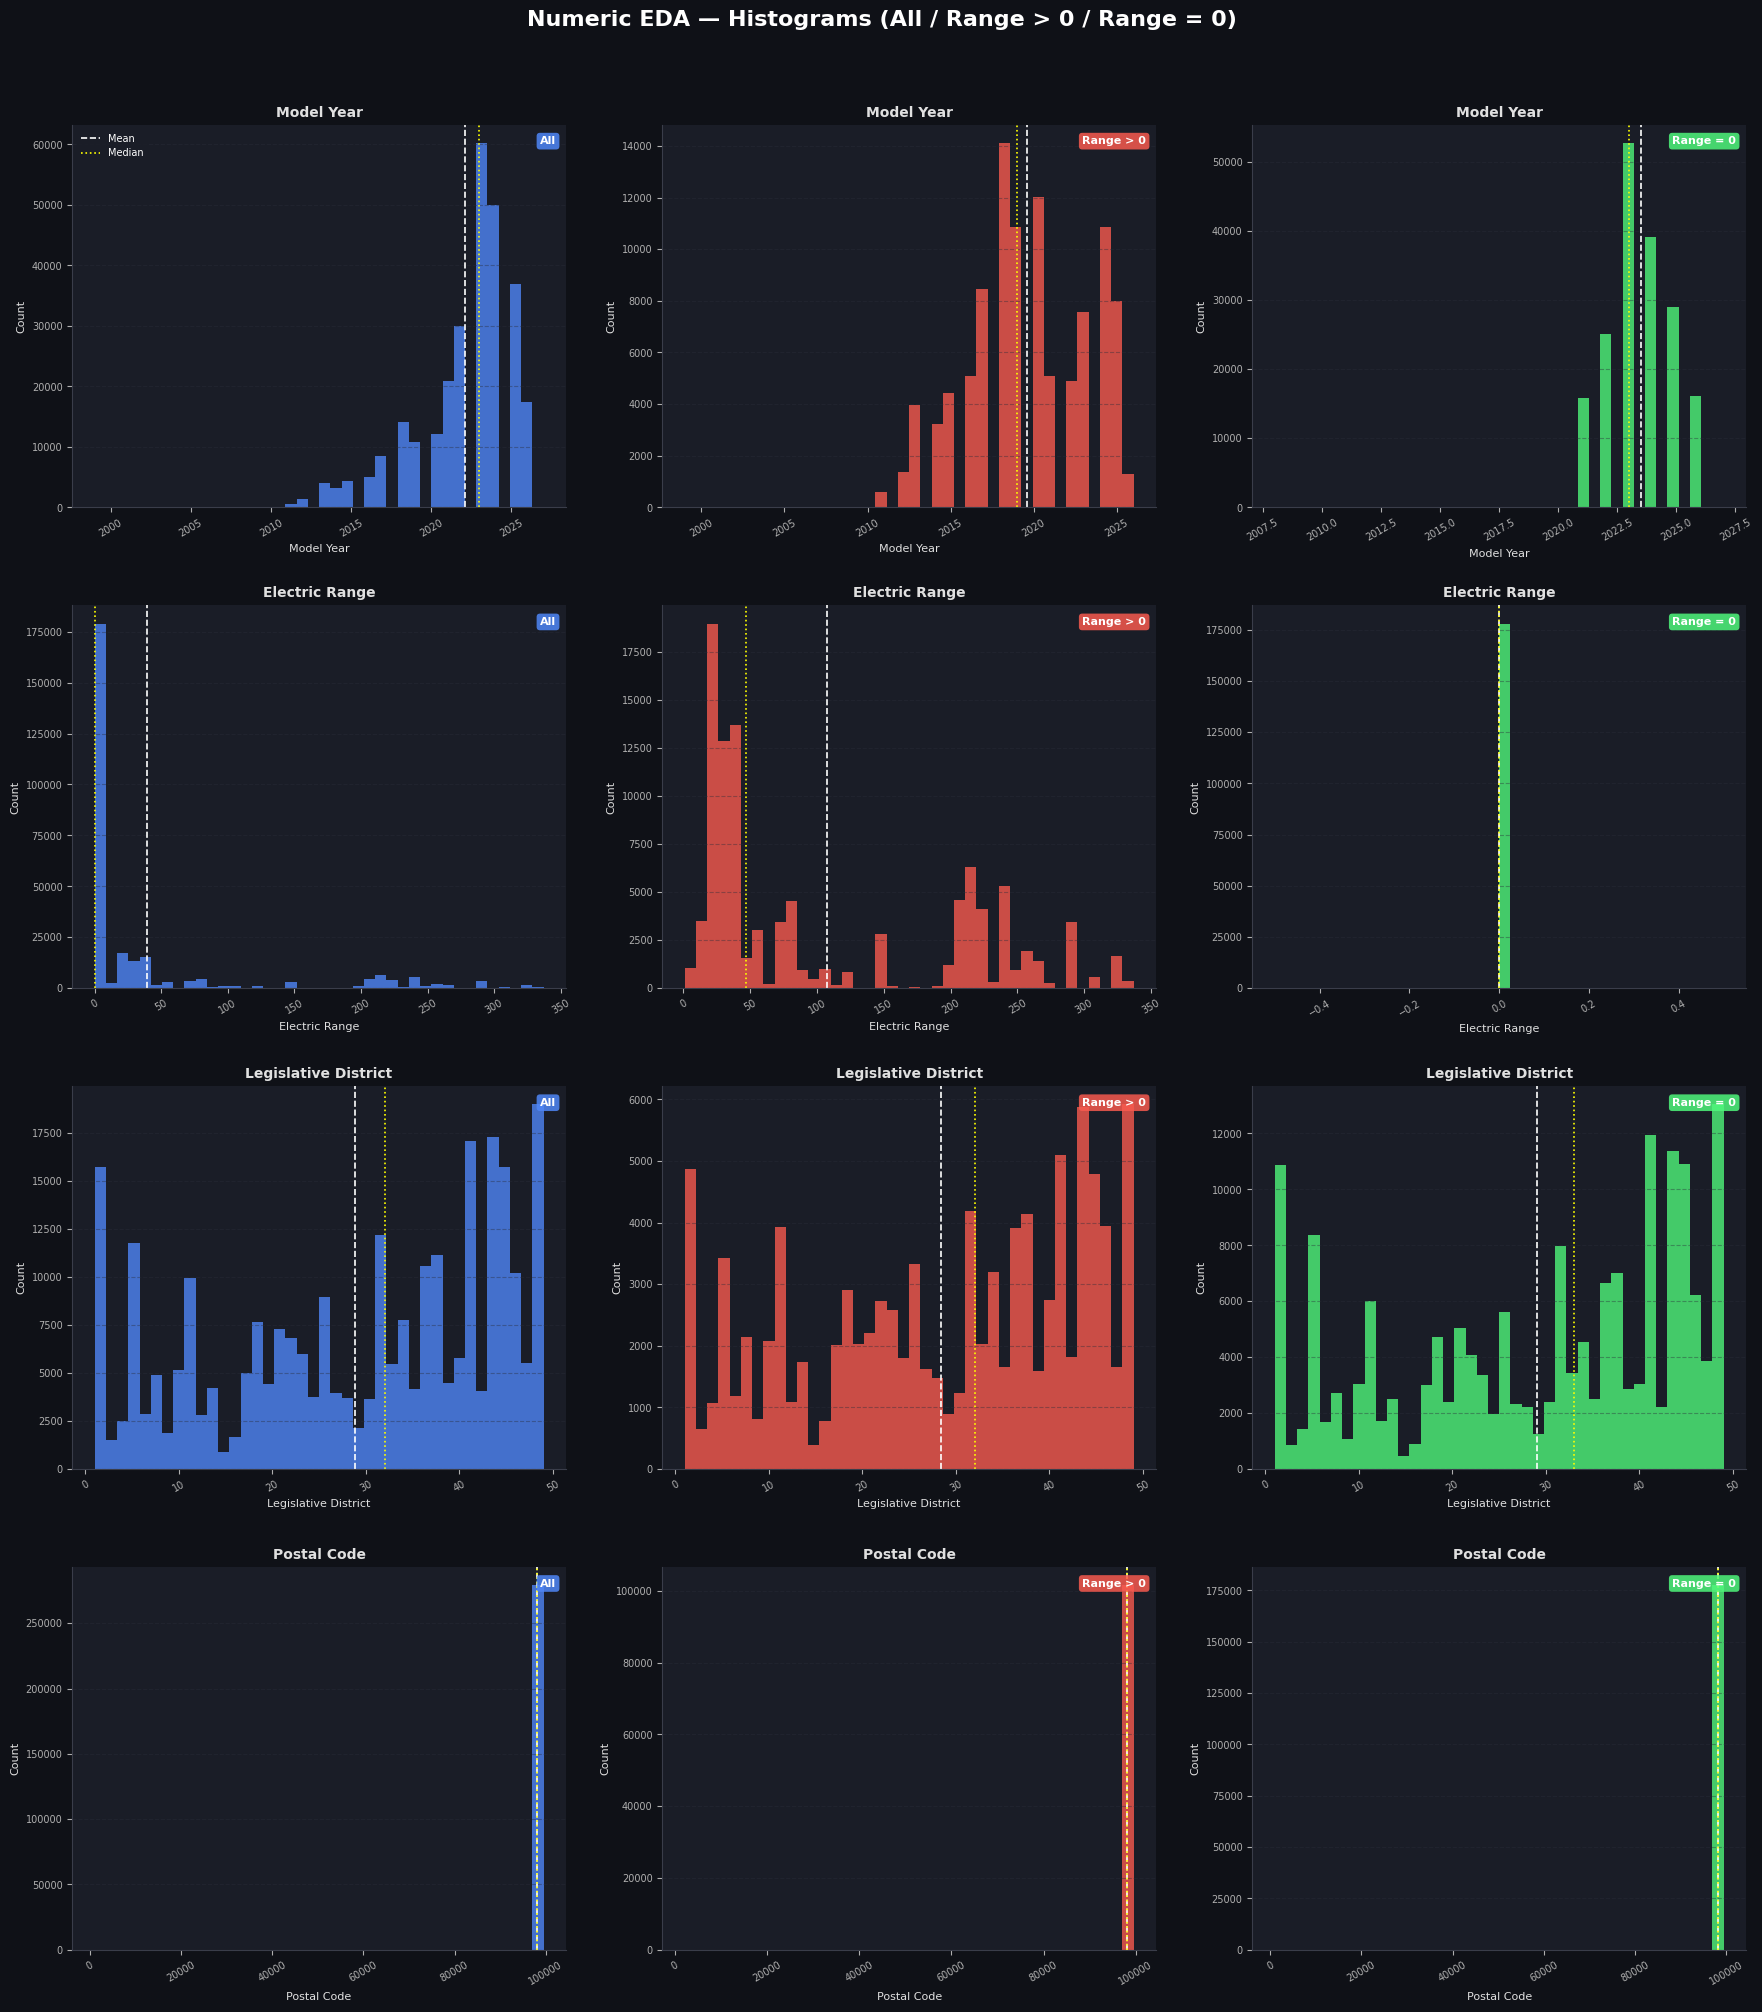

In [5]:
num_cols_plot = ['Model Year', 'Electric Range', 'Legislative District', 'Postal Code']

fig, axes = plt.subplots(
    len(num_cols_plot), 3,
    figsize=(18, 5 * len(num_cols_plot)),
    facecolor='#0F1117'
)
fig.suptitle('Numeric EDA — Histograms (All / Range > 0 / Range = 0)',
             fontsize=16, fontweight='bold', color='white', y=1.01)

for row, col in enumerate(num_cols_plot):
    for c_idx, (dset, lbl, clr) in enumerate(zip(datasets, labels, colors)):
        ax   = axes[row, c_idx]
        data = dset[col].dropna()

        ax.hist(data, bins=40, color=clr, alpha=ALPHA, edgecolor='none')
        style_ax(ax, title=col, xlabel=col, ylabel='Count')
        add_badge(ax, lbl, clr)

        ax.axvline(data.mean(),   color='white',  lw=1.2, linestyle='--', label='Mean')
        ax.axvline(data.median(), color='yellow', lw=1.2, linestyle=':',  label='Median')

        if row == 0 and c_idx == 0:
            ax.legend(fontsize=7, facecolor='#1A1D27', edgecolor='none', labelcolor='white')

plt.tight_layout(pad=2.0)
plt.show()

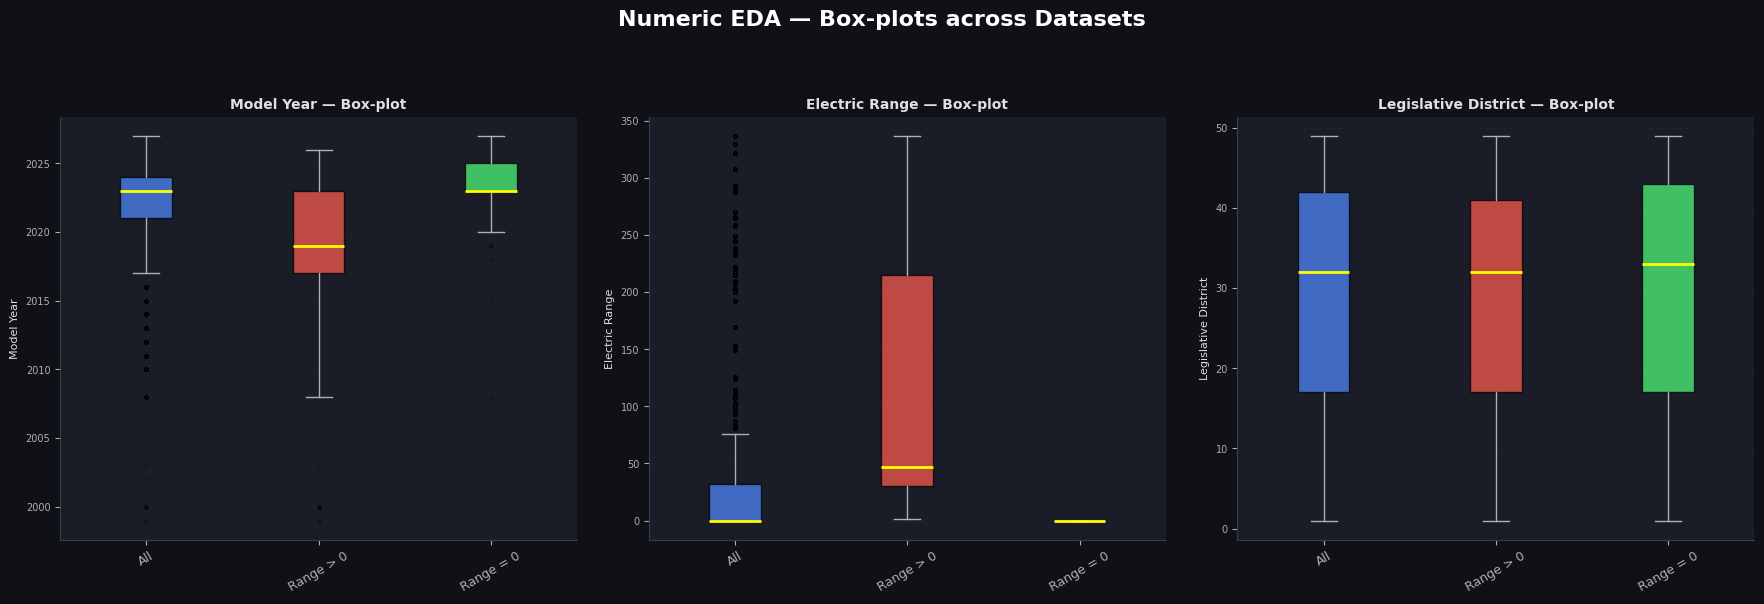

In [6]:
num_cols = ['Model Year', 'Electric Range', 'Legislative District']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0F1117')
fig.suptitle('Numeric EDA — Box-plots across Datasets',
             fontsize=16, fontweight='bold', color='white', y=1.02)

for ax, col in zip(axes, num_cols):
    box_data = [dset[col].dropna() for dset in datasets]

    bp = ax.boxplot(
        box_data,
        patch_artist=True,
        notch=False,
        medianprops=dict(color='yellow', linewidth=2),
        whiskerprops=dict(color='#B0B0B0'),
        capprops=dict(color='#B0B0B0'),
        flierprops=dict(marker='o', color='#B0B0B0', alpha=0.2, markersize=2)
    )
    for patch, clr in zip(bp['boxes'], colors):
        patch.set_facecolor(clr)
        patch.set_alpha(0.75)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(labels, fontsize=9)
    style_ax(ax, title=f'{col} — Box-plot', ylabel=col)

plt.tight_layout(pad=2.0)
plt.show()

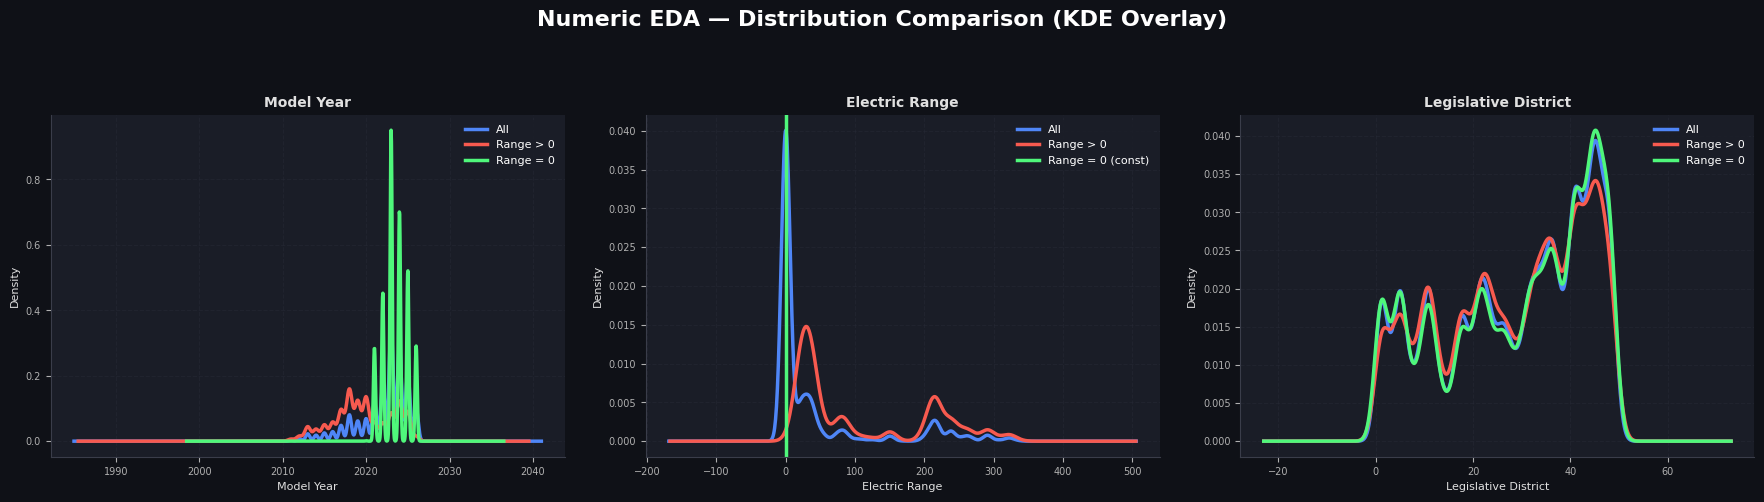

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0F1117')
fig.suptitle('Numeric EDA — Distribution Comparison (KDE Overlay)',
             fontsize=16, fontweight='bold', color='white', y=1.02)

for ax, col in zip(axes, num_cols):
    for dset, lbl, clr in zip(datasets, labels, colors):
        data = dset[col].dropna()
        if data.nunique() <= 1:
            ax.axvline(data.iloc[0] if len(data) else 0,
                       color=clr, linewidth=2.5, label=f'{lbl} (const)')
        else:
            data.plot.kde(ax=ax, label=lbl, color=clr, linewidth=2.5)

    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8, facecolor='#1A1D27', edgecolor='none', labelcolor='white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, alpha=0.4)

plt.tight_layout(pad=2.0)
plt.show()

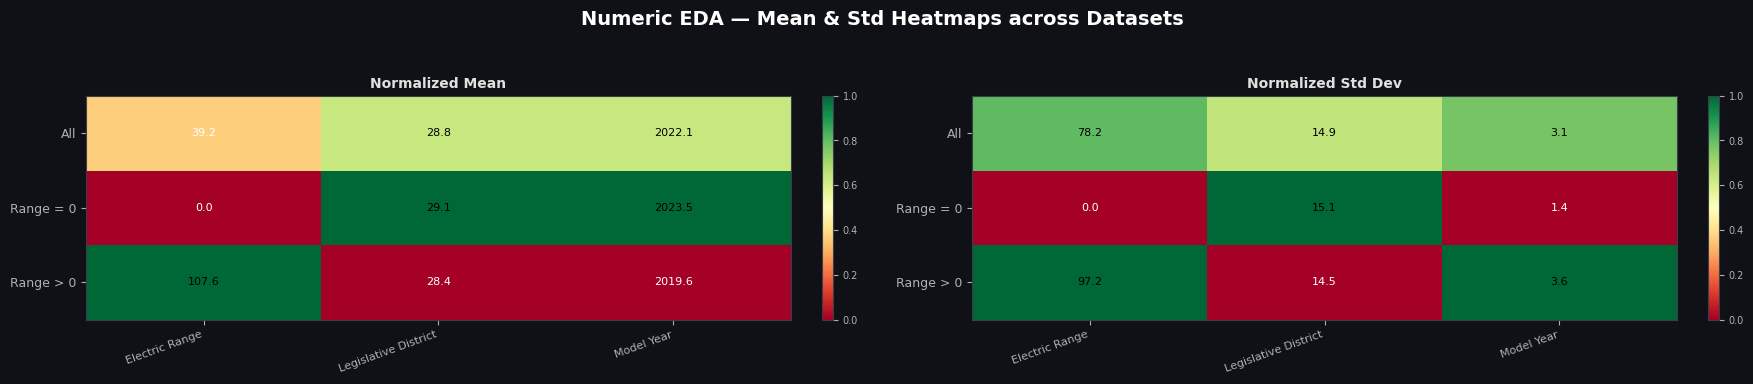

In [8]:
stat_rows = []
for dset, lbl in zip(datasets, labels):
    stats = dset[num_cols].describe().T
    stats.insert(0, 'Dataset', lbl)
    stat_rows.append(stats)

stats_df   = pd.concat(stat_rows)
pivot_mean = stats_df.pivot_table(index='Dataset', values='mean',
                                   columns=stats_df.index.get_level_values(0))
pivot_std  = stats_df.pivot_table(index='Dataset', values='std',
                                   columns=stats_df.index.get_level_values(0))

fig, axes = plt.subplots(1, 2, figsize=(18, 4), facecolor='#0F1117')
fig.suptitle('Numeric EDA — Mean & Std Heatmaps across Datasets',
             fontsize=14, fontweight='bold', color='white')

for ax, piv, title_s in zip(axes, [pivot_mean, pivot_std], ['Mean', 'Std Dev']):
    norm_piv = piv.apply(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9))
    im = ax.imshow(norm_piv.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

    ax.set_xticks(range(len(norm_piv.columns)))
    ax.set_xticklabels(norm_piv.columns, rotation=20, ha='right', fontsize=8)
    ax.set_yticks(range(len(norm_piv.index)))
    ax.set_yticklabels(norm_piv.index, fontsize=9)
    ax.set_title(f'Normalized {title_s}', fontweight='bold')

    for i in range(len(norm_piv.index)):
        for j in range(len(norm_piv.columns)):
            val = piv.values[i, j]
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    fontsize=8,
                    color='black' if norm_piv.values[i, j] > 0.5 else 'white')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout(pad=2.0)
plt.show()

Section 2: Categorical EDA
Analyzing frequencies and shares for Makes, Counties, EV Types, and more.

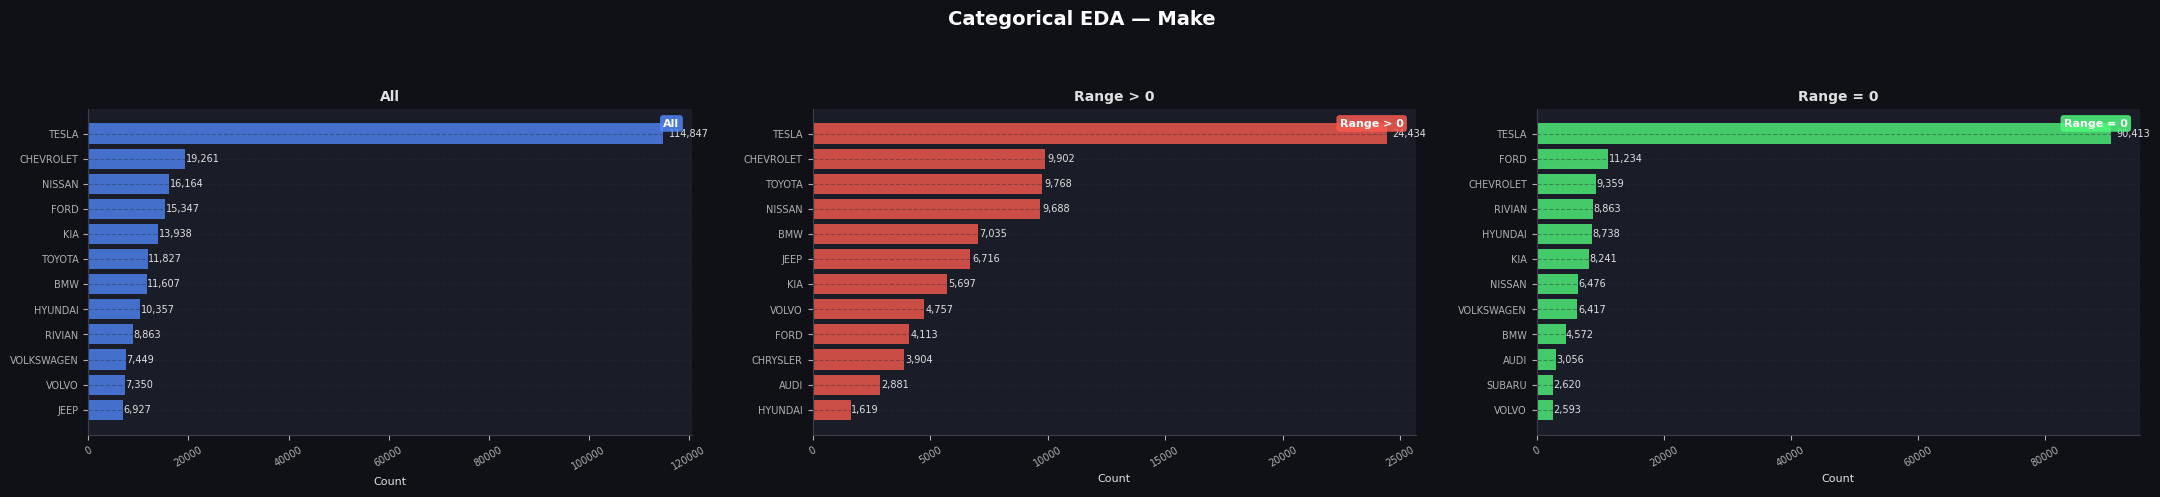

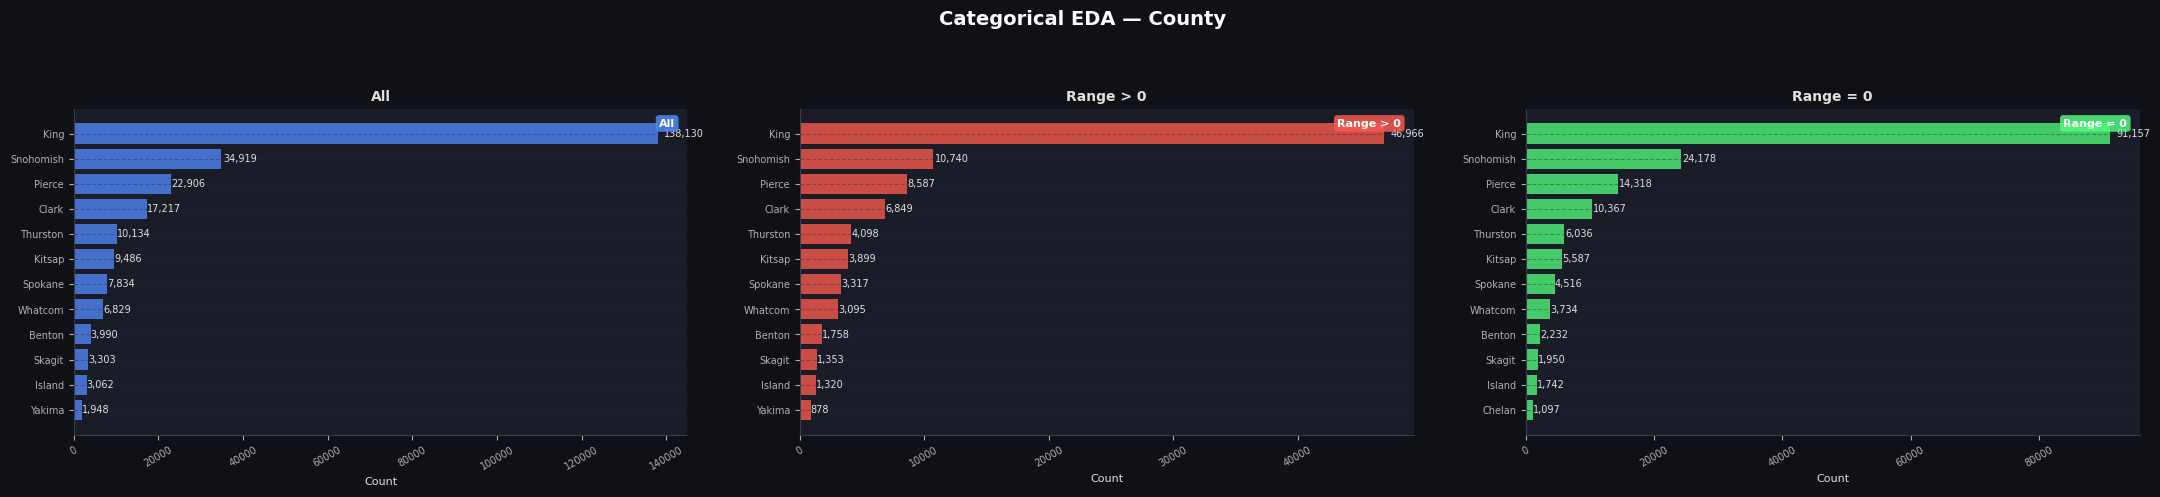

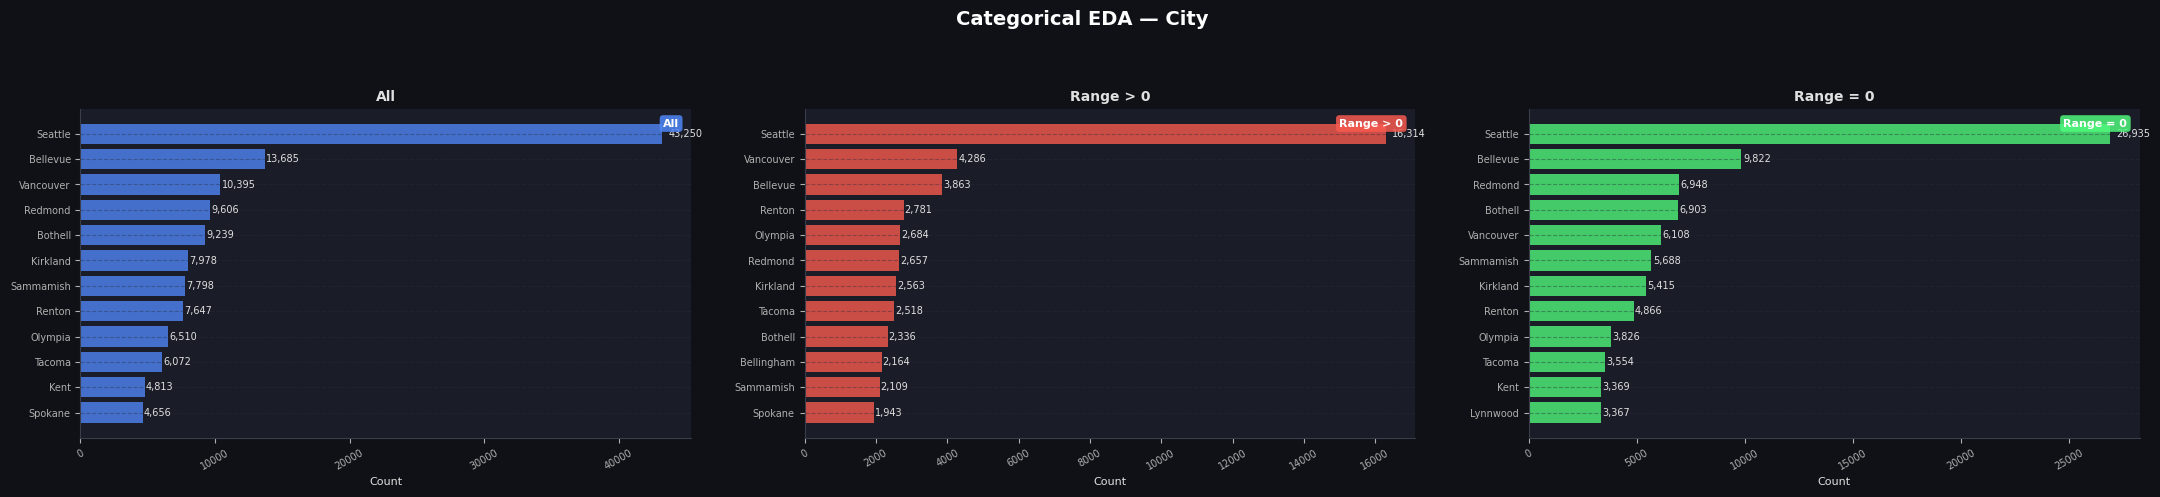

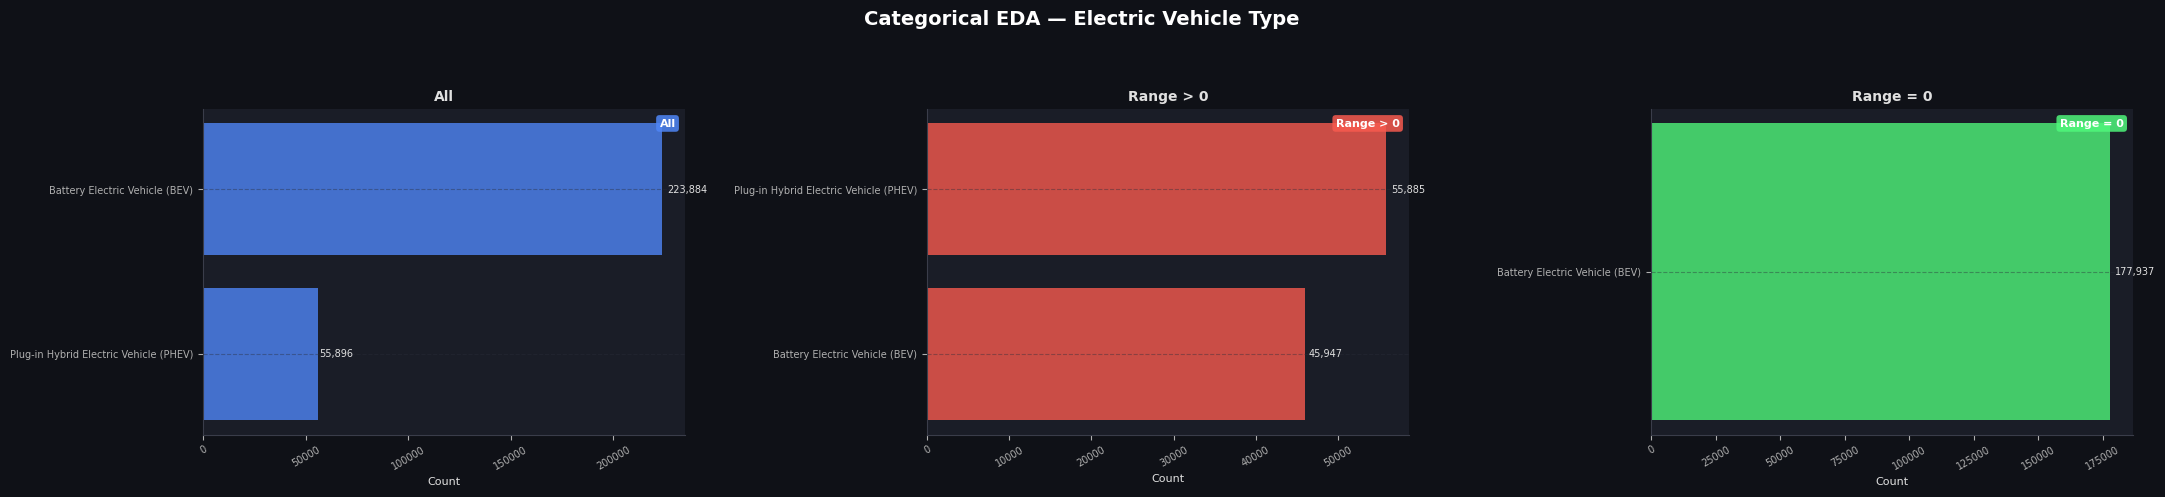

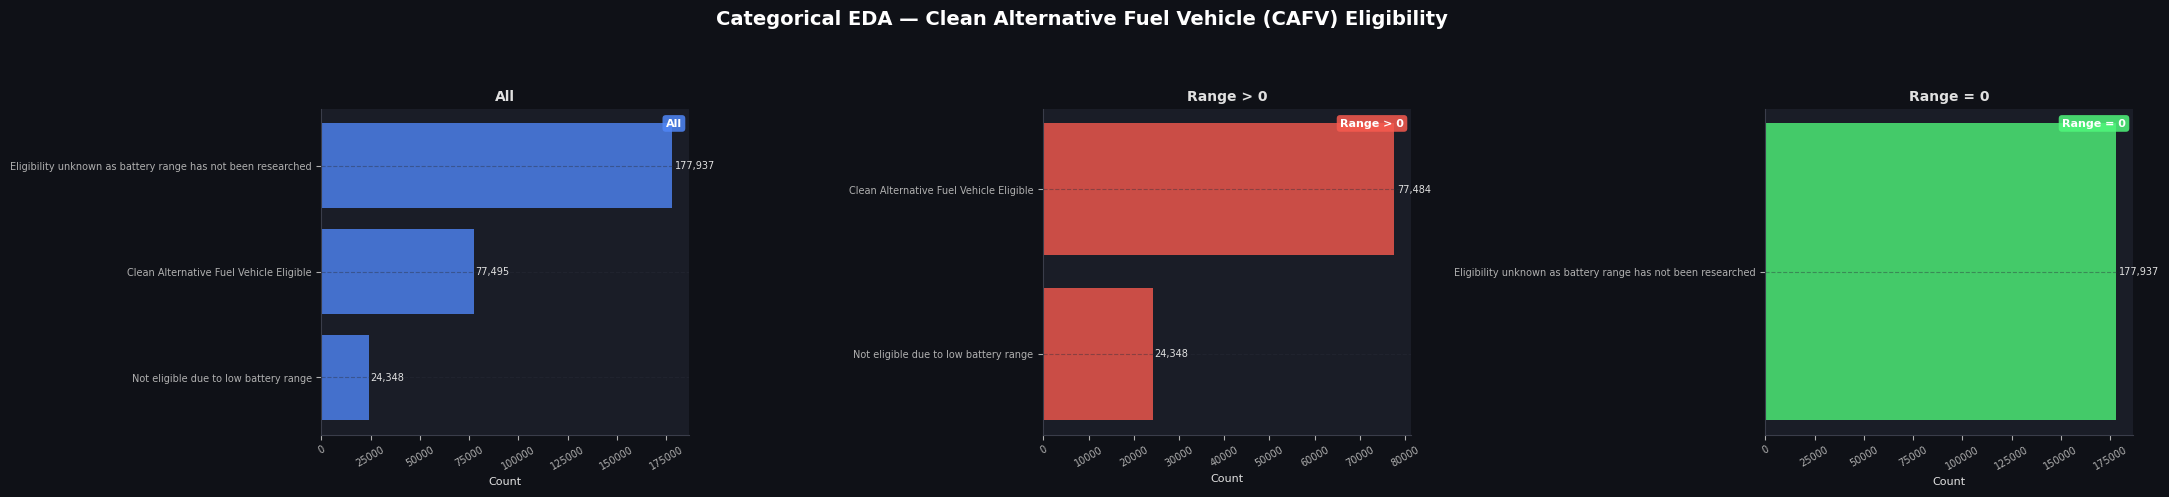

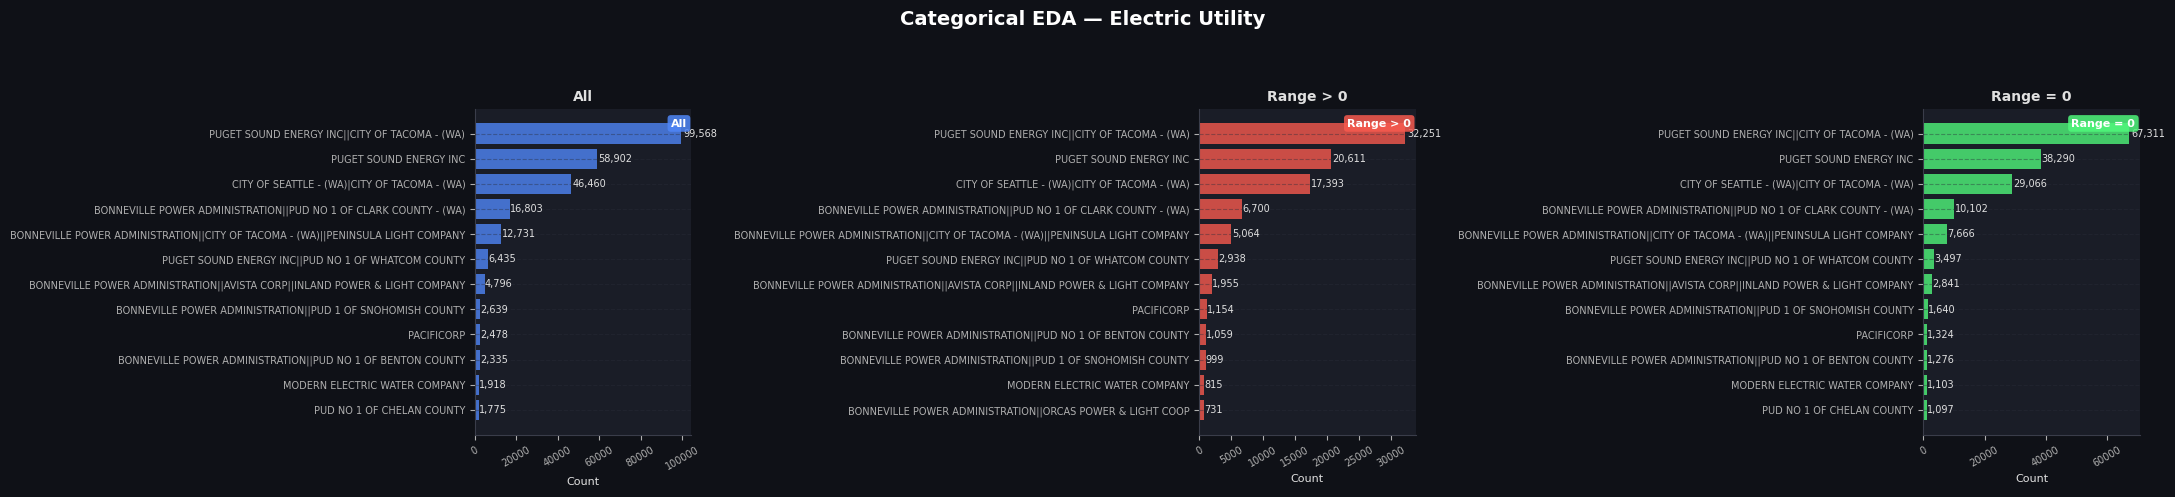

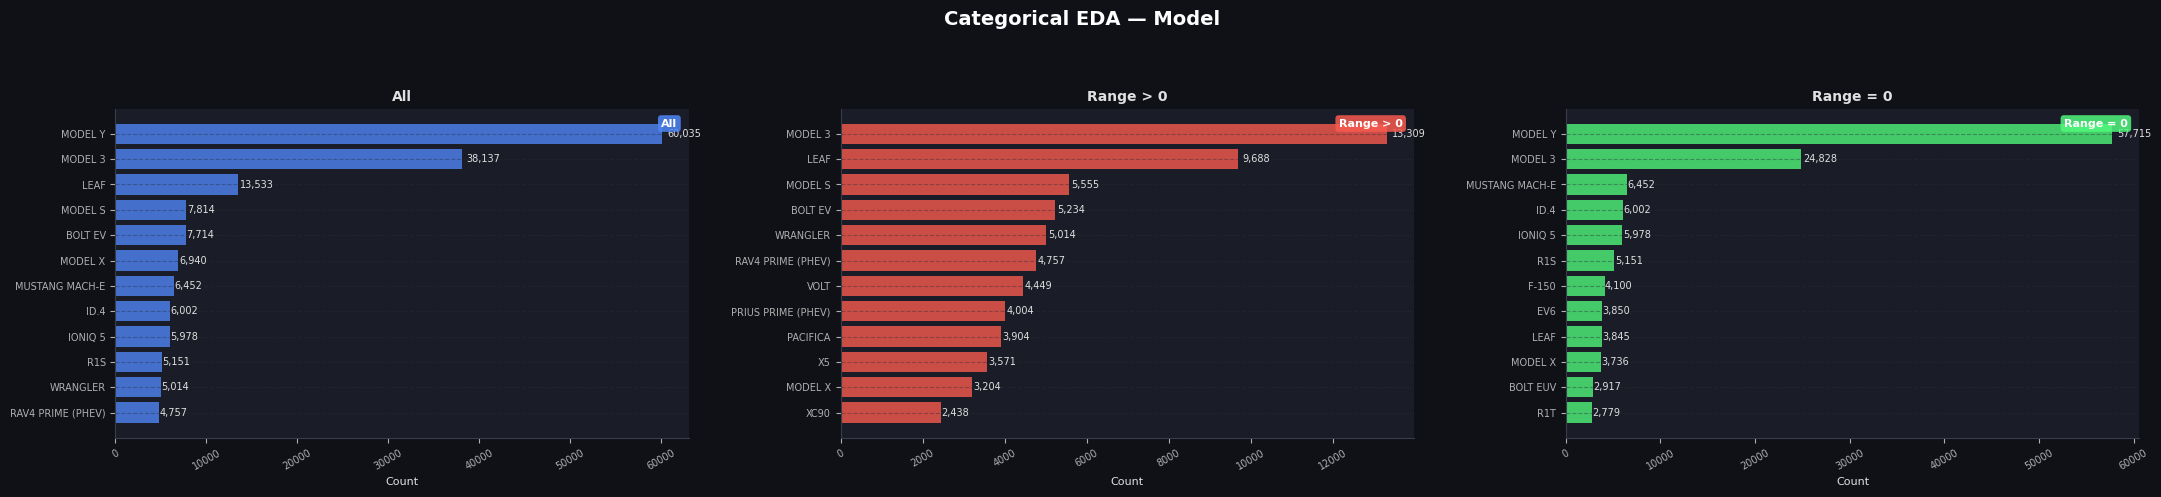

In [9]:
TOP_N = 12
categories = ['Make', 'County', 'City', 'Electric Vehicle Type', 
              'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Utility', 'Model']

for cat in categories:
    fig, axes = plt.subplots(1, 3, figsize=(22, 5), facecolor='#0F1117')
    fig.suptitle(f'Categorical EDA — {cat}', fontsize=14, fontweight='bold', color='white', y=1.01)

    for ax, dset, lbl, clr in zip(axes, datasets, labels, colors):
        counts = dset[cat].value_counts().head(TOP_N)
        bars   = ax.barh(counts.index[::-1], counts.values[::-1],
                         color=clr, alpha=ALPHA, edgecolor='none')
        for bar, val in zip(bars, counts.values[::-1]):
            ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                    f'{val:,}', va='center', fontsize=7, color='#E0E0E0')
        style_ax(ax, title=lbl, xlabel='Count', ylabel='')
        add_badge(ax, lbl, clr)
        ax.tick_params(axis='y', labelsize=7)
    
    plt.tight_layout(pad=2.0)
    plt.show()

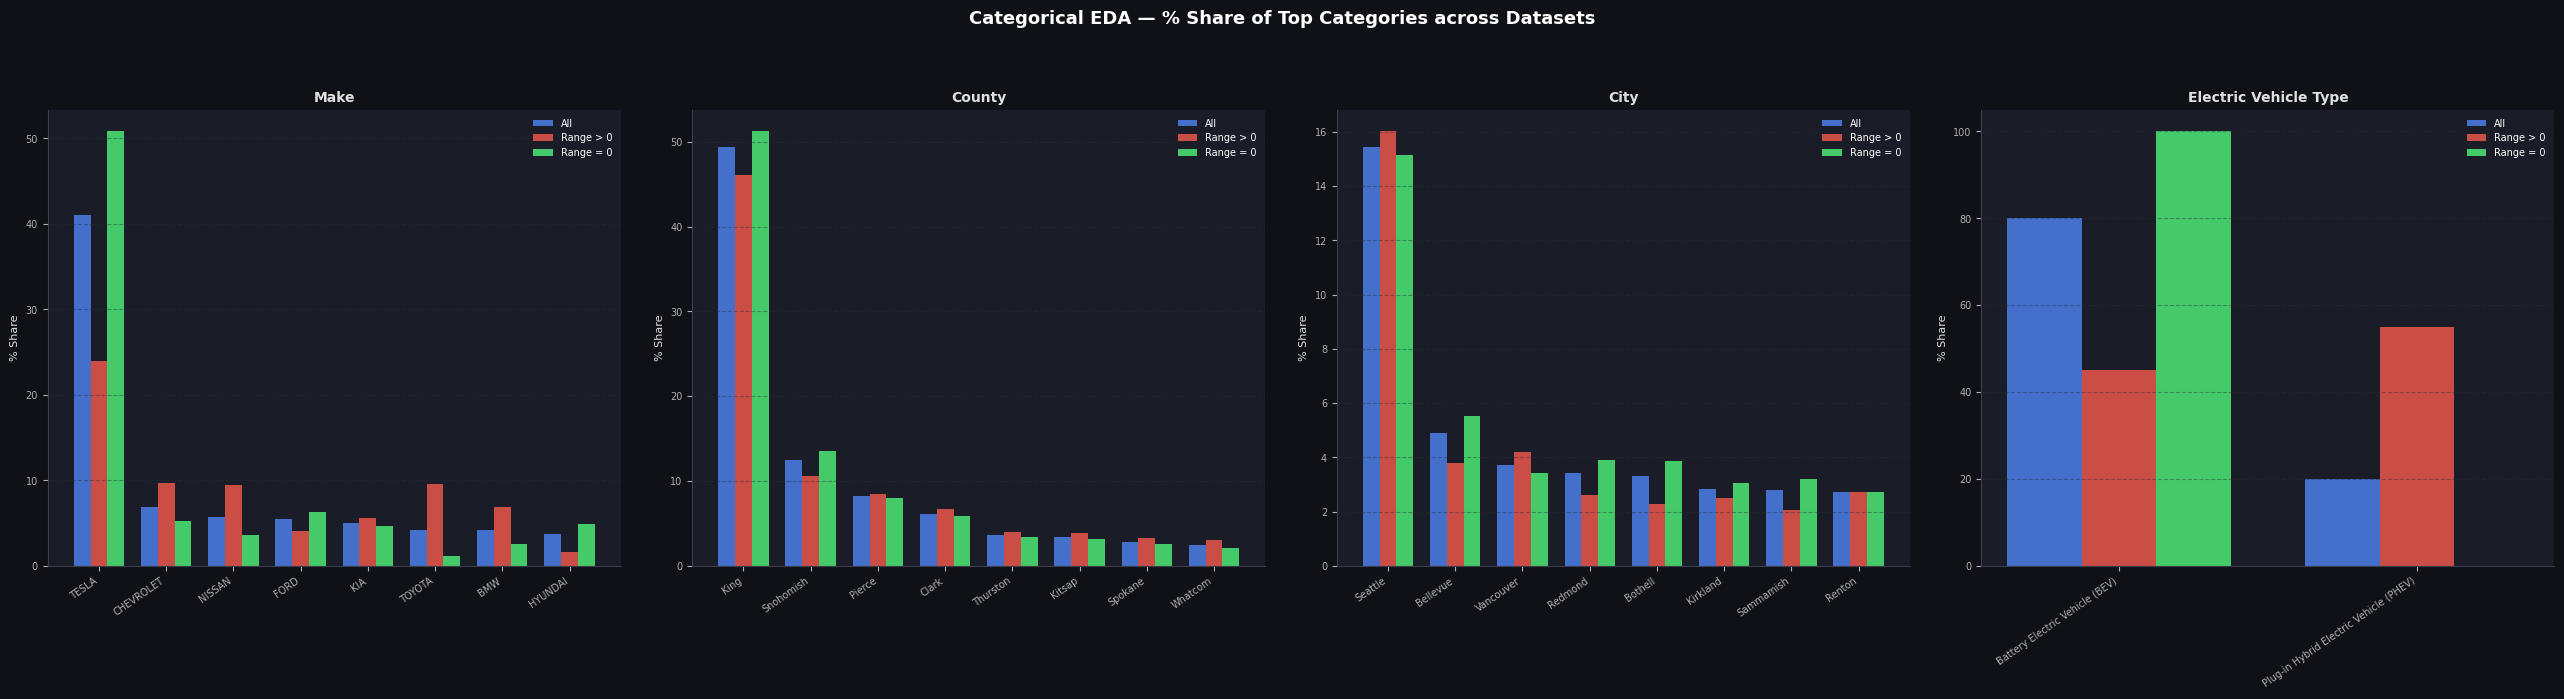

In [10]:
compare_cats = ['Make', 'County', 'City', 'Electric Vehicle Type']

fig, axes = plt.subplots(1, 4, figsize=(26, 7), facecolor='#0F1117')
fig.suptitle('Categorical EDA — % Share of Top Categories across Datasets',
             fontsize=13, fontweight='bold', color='white', y=1.01)

for ax, cat in zip(axes, compare_cats):
    top_cats = df[cat].value_counts().head(8).index
    x        = np.arange(len(top_cats))
    width    = 0.25

    for i, (dset, lbl, clr) in enumerate(zip(datasets, labels, colors)):
        counts = dset[cat].value_counts()
        pcts   = [(counts.get(c, 0) / len(dset) * 100) for c in top_cats]
        ax.bar(x + i * width, pcts, width,
               label=lbl, color=clr, alpha=ALPHA, edgecolor='none')

    ax.set_xticks(x + width)
    ax.set_xticklabels(top_cats, rotation=35, ha='right', fontsize=7)
    ax.set_title(cat, fontweight='bold')
    ax.set_ylabel('% Share')
    ax.legend(fontsize=7, facecolor='#1A1D27', edgecolor='none', labelcolor='white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, axis='y', alpha=0.4)

plt.tight_layout(pad=2.0)
plt.show()

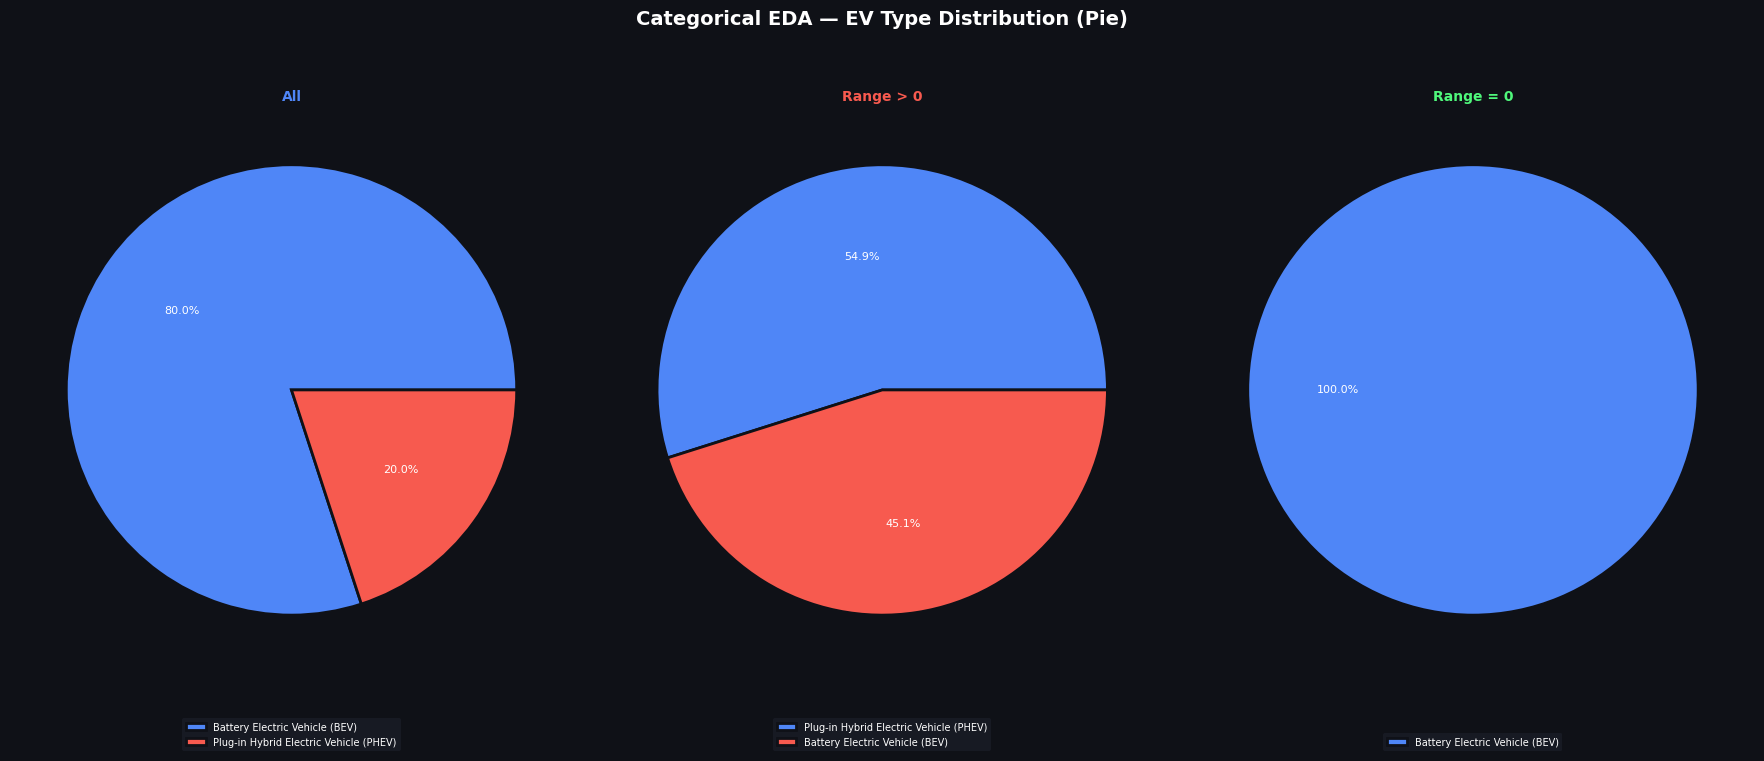

In [11]:
pie_colors = ['#4F86F7', '#F75A4F', '#4FF77B', '#F7C94F']

fig, axes = plt.subplots(1, 3, figsize=(18, 7), facecolor='#0F1117')
fig.suptitle('Categorical EDA — EV Type Distribution (Pie)',
             fontsize=14, fontweight='bold', color='white', y=1.01)

for ax, dset, lbl, ring_clr in zip(axes, datasets, labels, colors):
    vc = dset['Electric Vehicle Type'].value_counts()
    wedges, texts, autotexts = ax.pie(
        vc.values,
        labels=None,
        autopct='%1.1f%%',
        colors=pie_colors[:len(vc)],
        wedgeprops=dict(edgecolor='#0F1117', linewidth=2),
        textprops=dict(color='white', fontsize=8)
    )
    ax.legend(wedges, vc.index,
              loc='lower center', fontsize=7,
              facecolor='#1A1D27', edgecolor='none', labelcolor='white',
              bbox_to_anchor=(0.5, -0.15))
    ax.set_title(lbl, fontweight='bold', color=ring_clr)

plt.tight_layout(pad=2.0)
plt.show()

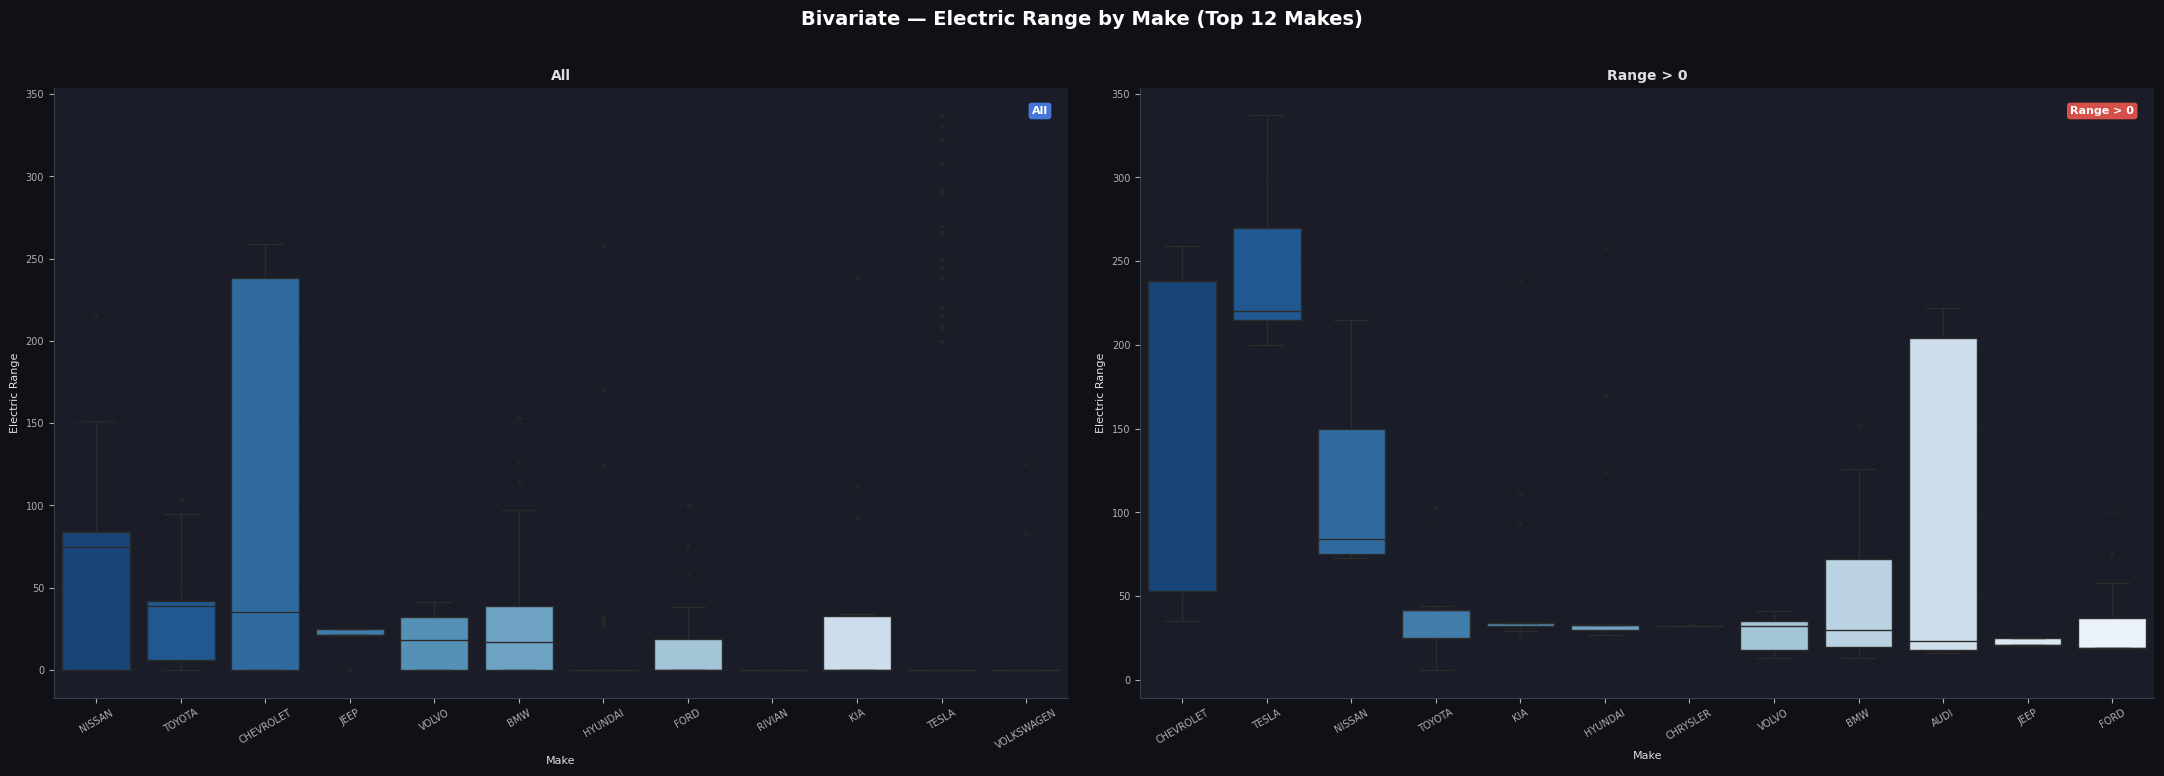

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8), facecolor='#0F1117')
fig.suptitle('Bivariate — Electric Range by Make (Top 12 Makes)',
             fontsize=14, fontweight='bold', color='white')

for ax, (dset, lbl, clr) in zip(axes, [(df, 'All', colors[0]),
                                         (df_pos, 'Range > 0', colors[1])]):
    top_makes = dset['Make'].value_counts().head(12).index
    sub       = dset[dset['Make'].isin(top_makes)]
    order     = (sub.groupby('Make')['Electric Range']
                    .median()
                    .sort_values(ascending=False)
                    .index)
    sns.boxplot(
        data=sub, x='Make', y='Electric Range', order=order,
        palette=sns.color_palette('Blues_r', 12), ax=ax,
        flierprops=dict(marker='o', alpha=0.2, markersize=2)
    )
    style_ax(ax, title=lbl, xlabel='Make', ylabel='Electric Range')
    add_badge(ax, lbl, clr)

plt.tight_layout(pad=2.0)
plt.show()

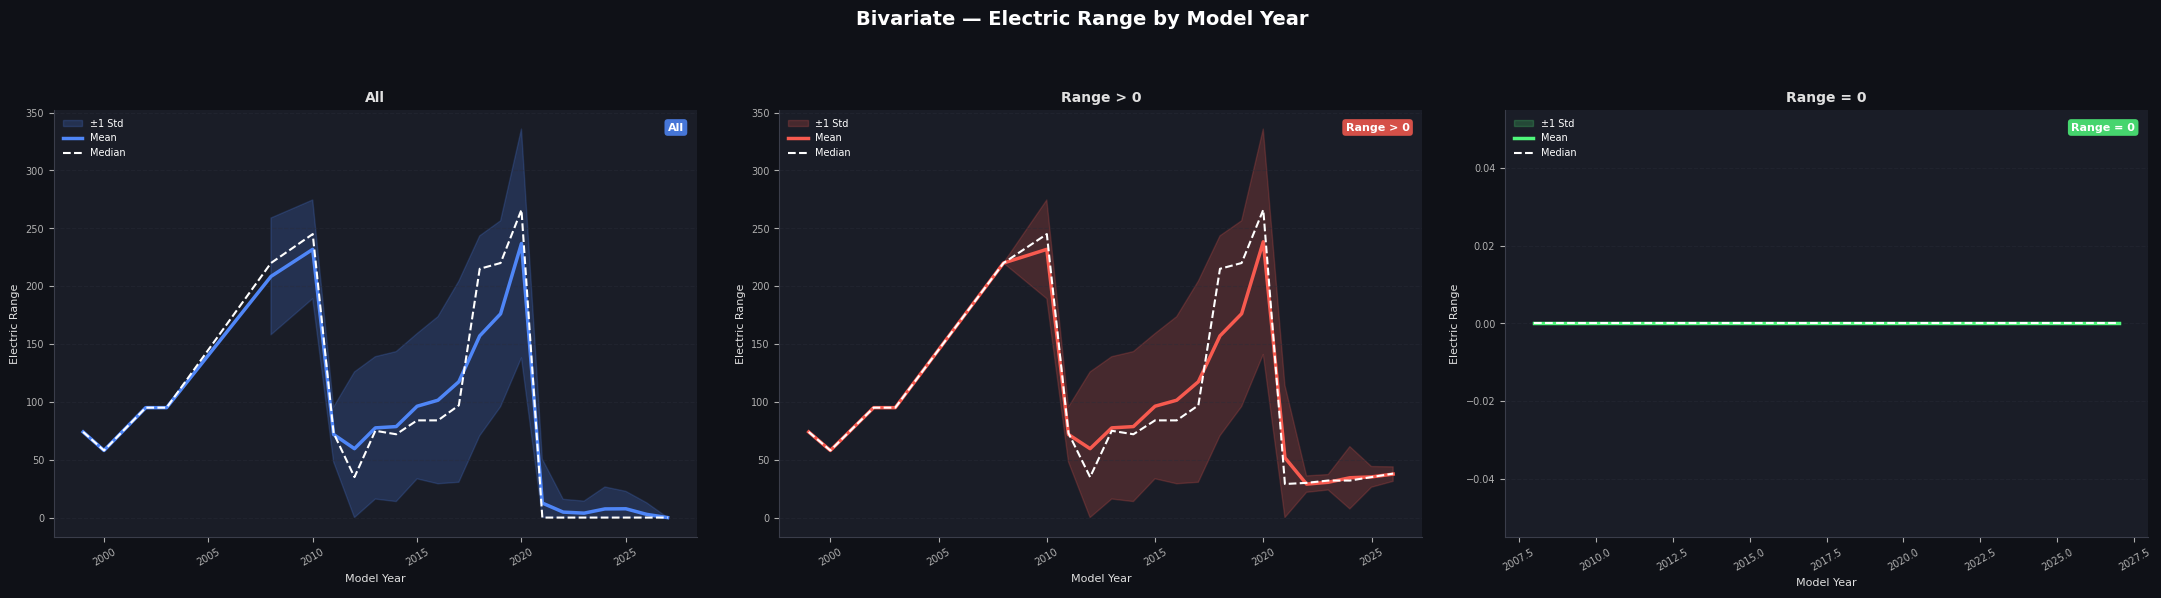

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6), facecolor='#0F1117')
fig.suptitle('Bivariate — Electric Range by Model Year',
             fontsize=14, fontweight='bold', color='white', y=1.01)

for ax, dset, lbl, clr in zip(axes, datasets, labels, colors):
    grp = (dset.groupby('Model Year')['Electric Range']
               .agg(['mean', 'median', 'std'])
               .reset_index())

    ax.fill_between(
        grp['Model Year'],
        (grp['mean'] - grp['std']).clip(lower=0),
        grp['mean'] + grp['std'],
        color=clr, alpha=0.2, label='±1 Std'
    )
    ax.plot(grp['Model Year'], grp['mean'],   color=clr,    linewidth=2.5, label='Mean')
    ax.plot(grp['Model Year'], grp['median'], color='white', linewidth=1.5,
            linestyle='--', label='Median')

    style_ax(ax, title=lbl, xlabel='Model Year', ylabel='Electric Range')
    add_badge(ax, lbl, clr)
    ax.legend(fontsize=7, facecolor='#1A1D27', edgecolor='none', labelcolor='white')

plt.tight_layout(pad=2.0)
plt.show()

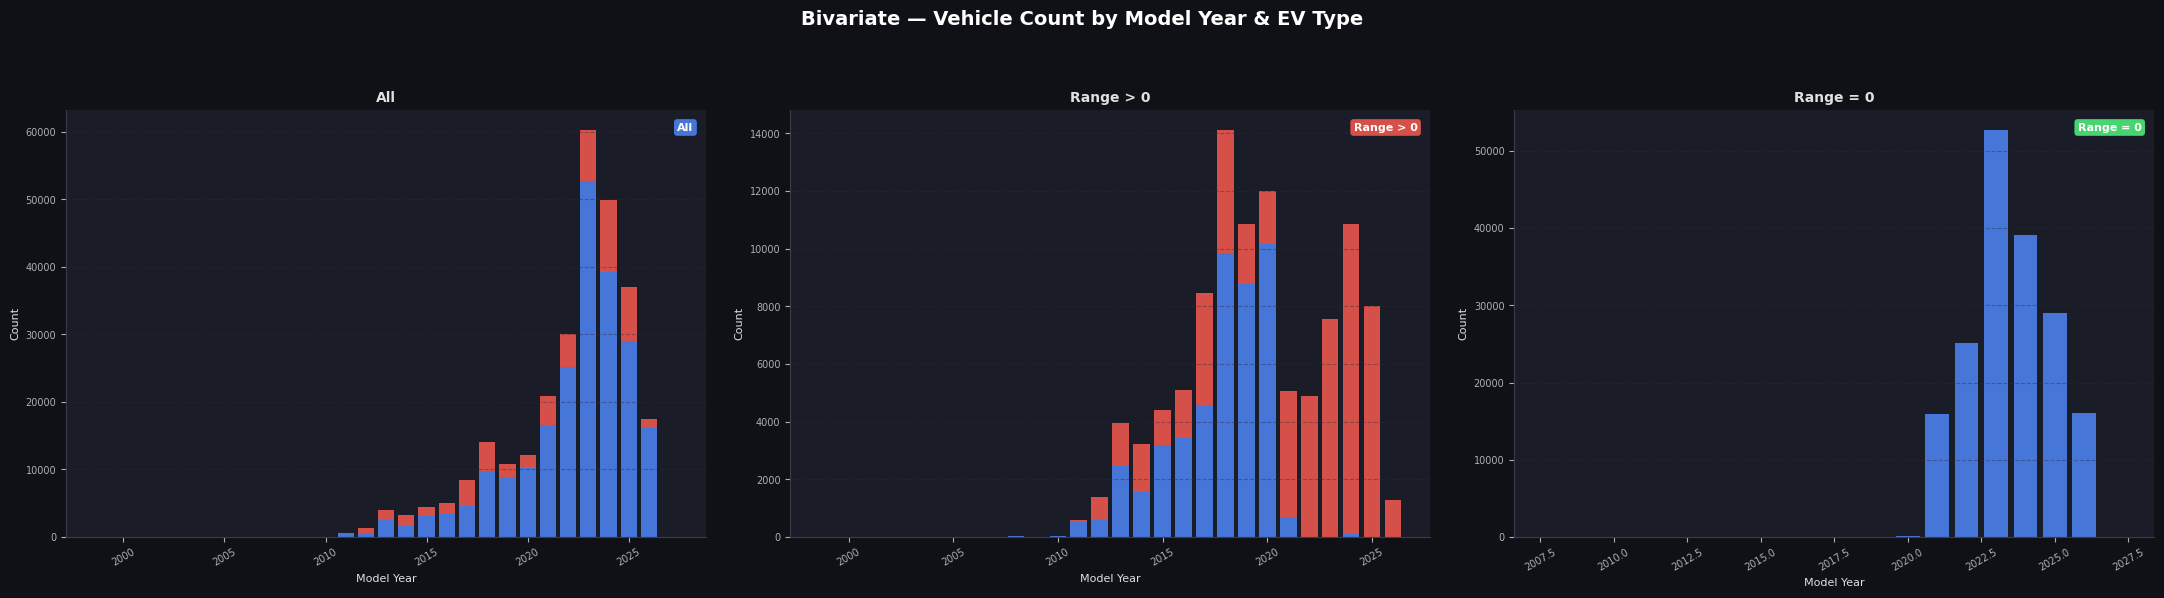

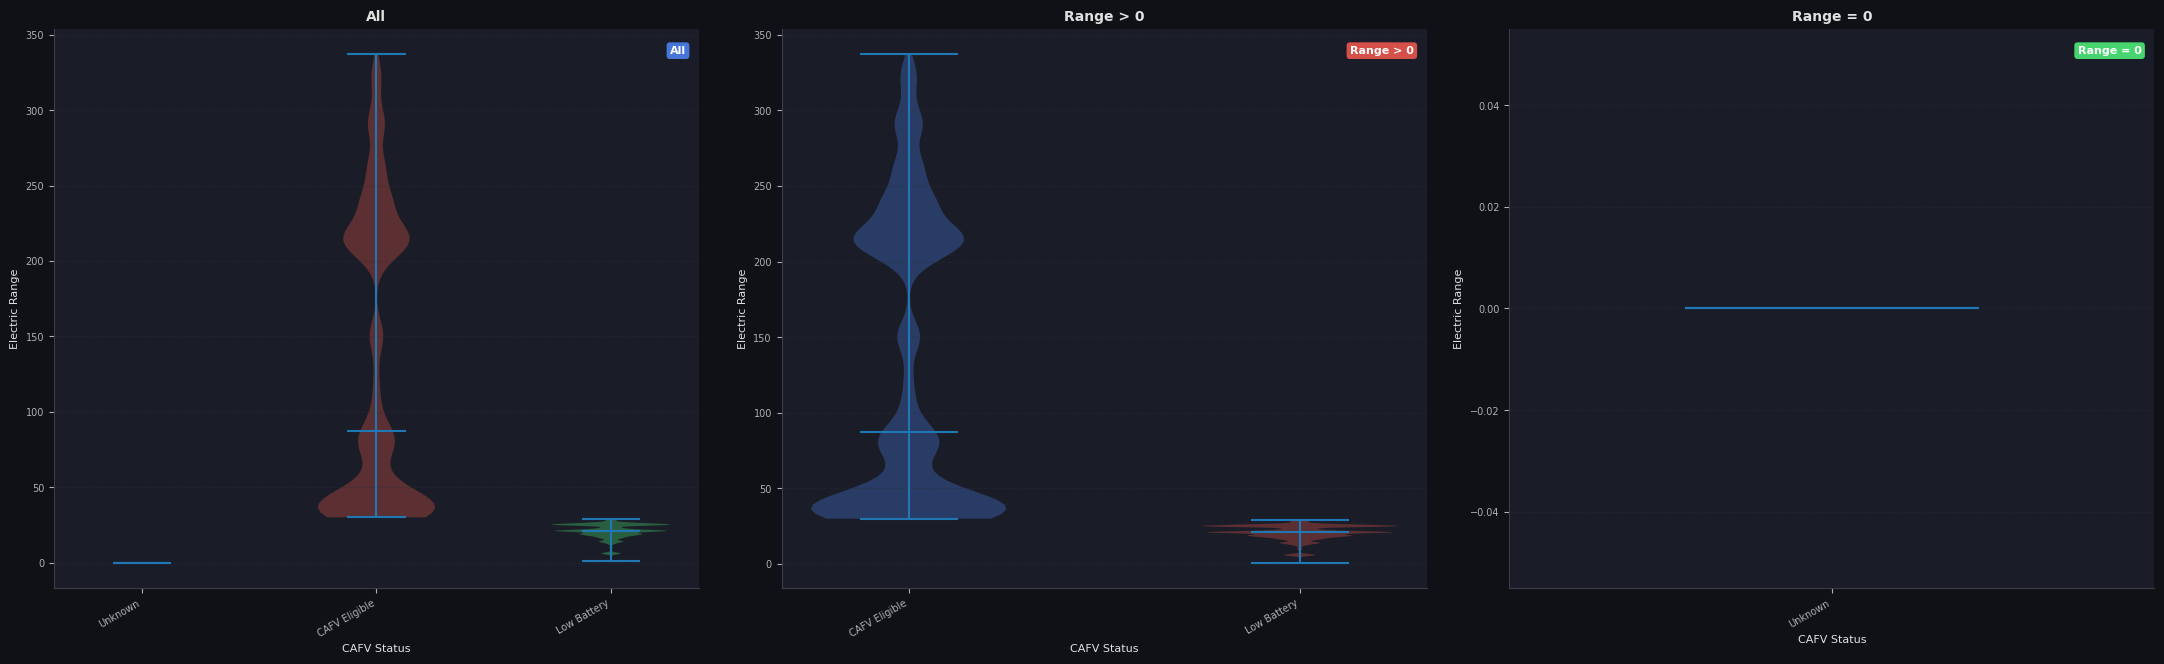

In [14]:
# Stacked Bar: Count by Year & Type
ev_colors = ['#4F86F7', '#F75A4F', '#4FF77B', '#F7C94F']
fig, axes = plt.subplots(1, 3, figsize=(22, 6), facecolor='#0F1117')
fig.suptitle('Bivariate — Vehicle Count by Model Year & EV Type', fontsize=14, fontweight='bold', color='white', y=1.01)

for ax, dset, lbl, clr in zip(axes, datasets, labels, colors):
    pivot = (dset.groupby(['Model Year', 'Electric Vehicle Type']).size().unstack(fill_value=0))
    years, bottoms = pivot.index, np.zeros(len(pivot.index))
    for j, col_ev in enumerate(pivot.columns):
        ax.bar(years, pivot[col_ev], bottom=bottoms, label=col_ev, color=ev_colors[j % 4], alpha=0.85)
        bottoms += pivot[col_ev].values
    style_ax(ax, title=lbl, xlabel='Model Year', ylabel='Count')
    add_badge(ax, lbl, clr)
plt.tight_layout(pad=2.0); plt.show()

# Violin Plot: Range by CAFV
cafv_short = {'Clean Alternative Fuel Vehicle Eligible': 'CAFV Eligible', 'Not eligible due to low battery range': 'Low Battery', 'Eligibility unknown as battery range has not been researched': 'Unknown'}
fig, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor='#0F1117')
for ax, dset, lbl, clr in zip(axes, datasets, labels, colors):
    sub = dset.copy(); sub['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] = sub['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].map(cafv_short).fillna(sub['Clean Alternative Fuel Vehicle (CAFV) Eligibility'])
    cats = sub['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts().index[:4]
    sub = sub[sub['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].isin(cats)]
    parts = ax.violinplot([sub[sub['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] == c]['Electric Range'].dropna() for c in cats], showmedians=True)
    for pc, pc_clr in zip(parts['bodies'], ev_colors): pc.set_facecolor(pc_clr)
    ax.set_xticks(range(1, len(cats) + 1)); ax.set_xticklabels(cats, rotation=20, ha='right', fontsize=7)
    style_ax(ax, title=lbl, xlabel='CAFV Status', ylabel='Electric Range'); add_badge(ax, lbl, clr)
plt.tight_layout(pad=2.0); plt.show()

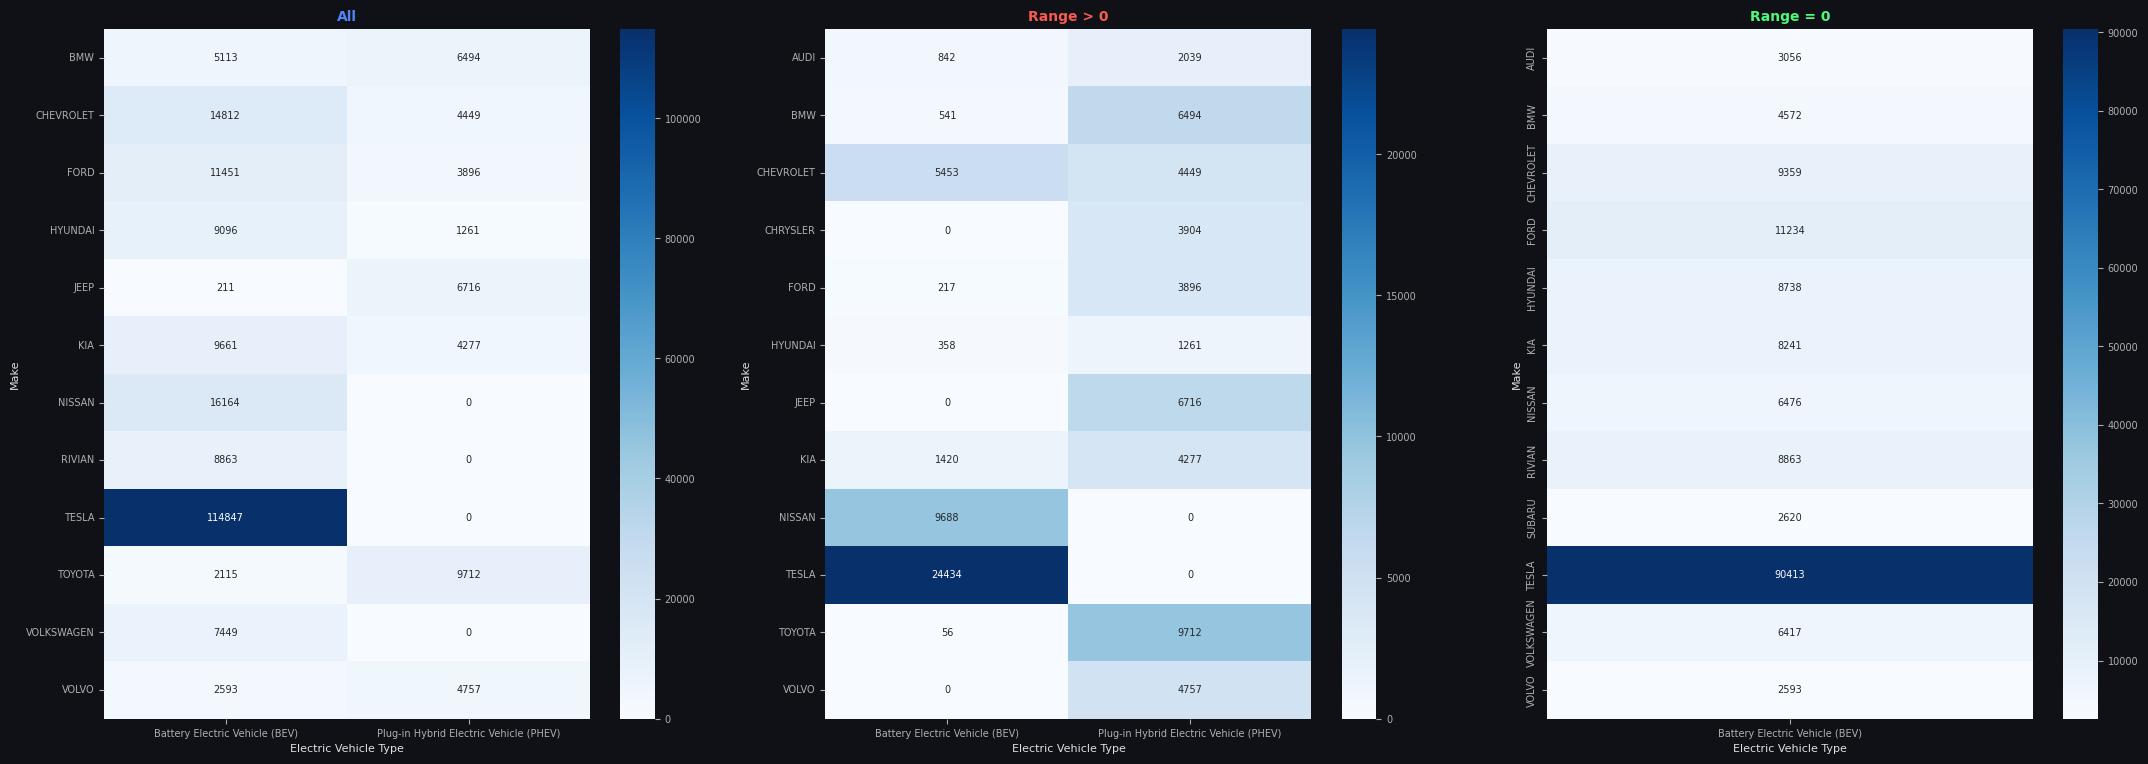

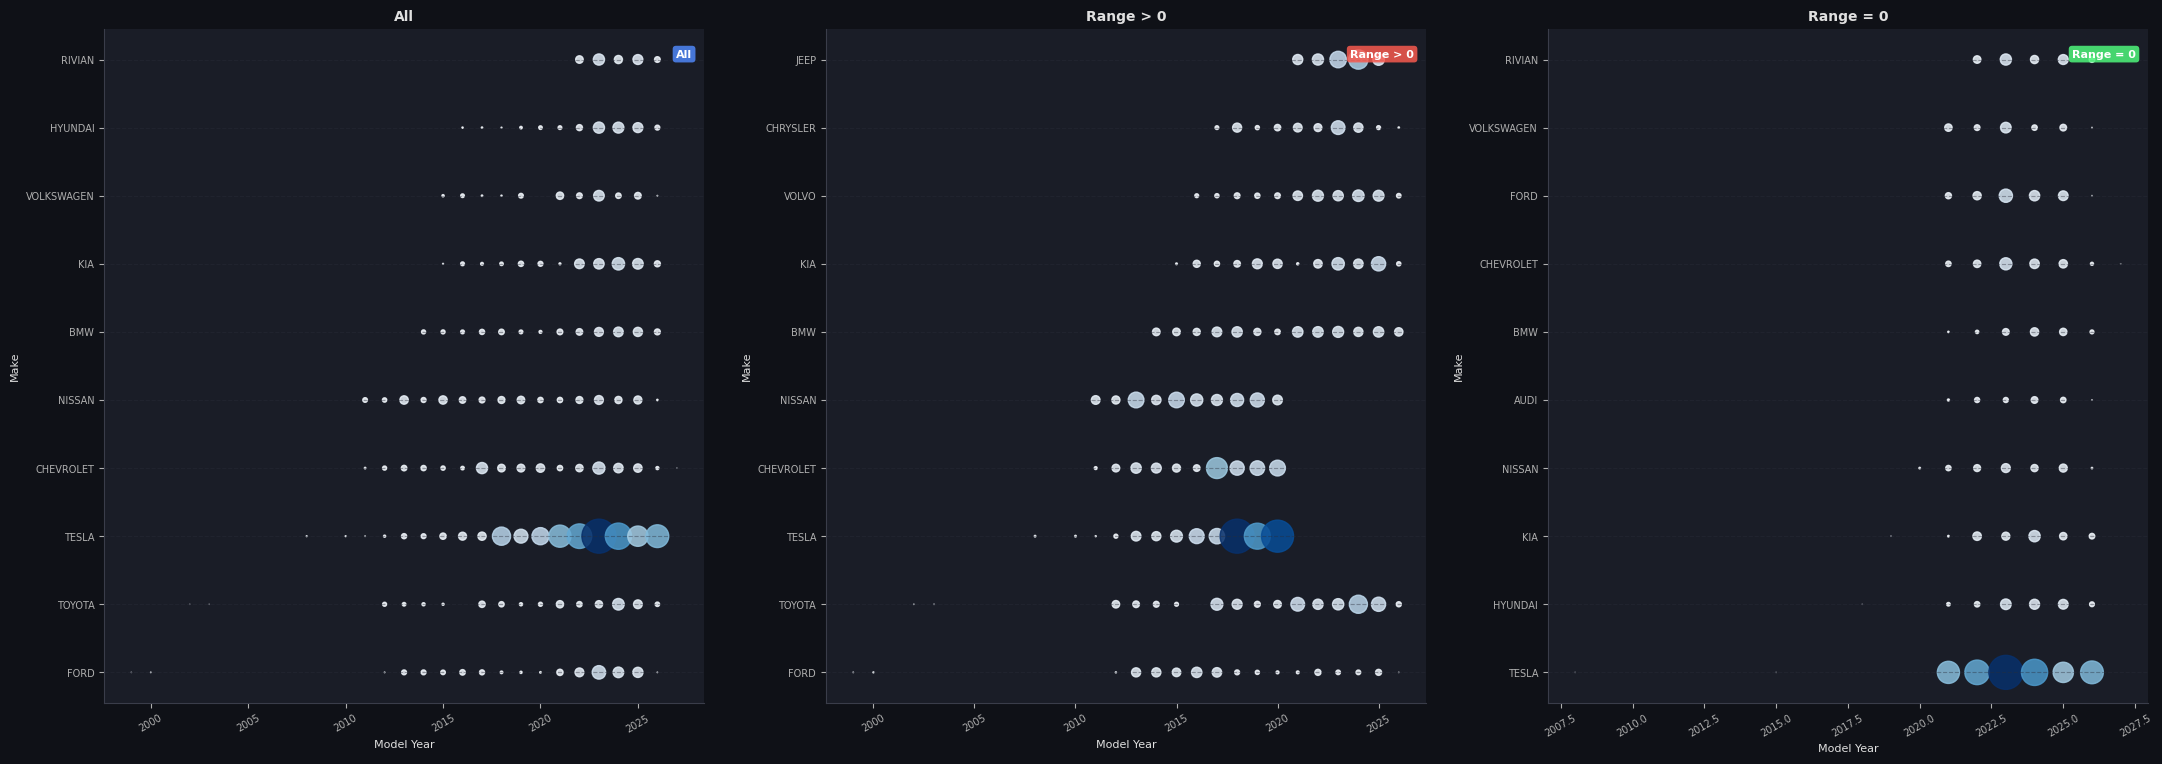


EDA Notebook Generation Complete!


In [15]:
# Make x EV Type Heatmap
fig, axes = plt.subplots(1, 3, figsize=(22, 8), facecolor='#0F1117')
for ax, dset, lbl, clr in zip(axes, datasets, labels, colors):
    top_makes = dset['Make'].value_counts().head(12).index
    pivot = (dset[dset['Make'].isin(top_makes)].groupby(['Make', 'Electric Vehicle Type']).size().unstack(fill_value=0))
    sns.heatmap(pivot, ax=ax, cmap='Blues', annot=True, fmt='d', annot_kws={'size': 7})
    ax.set_title(lbl, fontweight='bold', color=clr)
plt.tight_layout(pad=2.0); plt.show()

# Bubble Chart: Year vs Make
fig, axes = plt.subplots(1, 3, figsize=(22, 8), facecolor='#0F1117')
for ax, dset, lbl, clr in zip(axes, datasets, labels, colors):
    top_makes = dset['Make'].value_counts().head(10).index
    grp = (dset[dset['Make'].isin(top_makes)].groupby(['Model Year', 'Make']).size().reset_index(name='Count'))
    sc = ax.scatter(grp['Model Year'], grp['Make'], s=grp['Count'] / grp['Count'].max() * 600, c=grp['Count'], cmap='Blues', alpha=0.85)
    style_ax(ax, title=lbl, xlabel='Model Year', ylabel='Make'); add_badge(ax, lbl, clr)
plt.tight_layout(pad=2.0); plt.show()

print("\nEDA Notebook Generation Complete!")